# Data Postprocessing

In [2]:
import glob
import os
import pickle
import re
import numpy as np

# --- KONFIGURASI PATH ---
folder_path = "checkpoint_jobs"  # Pastikan path ini benar
# Pola file awal (menangkap semua .pkl)
file_pattern = os.path.join(folder_path, "*.pkl")

print(f"📂 Target direktori: {folder_path}")

📂 Target direktori: checkpoint_jobs


In [3]:
# ==========================================
# BAGIAN 1: RENAME FILE OTOMATIS
# ==========================================
print("\n--- [1] MEMULAI PROSES RENAME FILE ---")

# Mapping dari nama lama ke nama baru
rename_map = {
    "ciae": "iae",
    "cise": "ise",
    "citae": "itae",
    "citse": "itse"
    # Tambahkan mapping lain jika ada variasi lain (misal: "hoa_cappiello" -> "hoa")
}

files = glob.glob(file_pattern)
renamed_count = 0

for filepath in files:
    filename = os.path.basename(filepath)
    new_filename = filename
    
    # Cek apakah filename mengandung salah satu key dari map
    for old_str, new_str in rename_map.items():
        if old_str in filename:
            new_filename = filename.replace(old_str, new_str)
            break  # Pindah ke file berikutnya setelah match
    
    # Lakukan rename jika nama berubah
    if new_filename != filename:
        old_path = os.path.join(folder_path, filename)
        new_path = os.path.join(folder_path, new_filename)
        
        try:
            os.rename(old_path, new_path)
            # print(f"✅ Renamed: {filename} -> {new_filename}") # Uncomment jika ingin log per file
            renamed_count += 1
        except OSError as e:
            print(f"❌ Gagal rename {filename}: {e}")

if renamed_count > 0:
    print(f"✨ Sukses mengubah nama {renamed_count} file.")
else:
    print("ℹ️ Tidak ada file yang perlu di-rename (atau nama file sudah format baru).")


--- [1] MEMULAI PROSES RENAME FILE ---
ℹ️ Tidak ada file yang perlu di-rename (atau nama file sudah format baru).


In [4]:
# ==========================================
# BAGIAN 2: AGREGASI DATA (LOGIKA UTAMA)
# ==========================================
print("\n--- [2] MEMULAI PROSES AGREGASI DATA ---")

# Update pattern agar hanya mengambil file yang sudah sesuai format baru
# Format target: acc_run_0_ga_ciae.pkl
# Regex: (System)_run_(ID)_(Algo)_(Objective).pkl
files = glob.glob(file_pattern) 
filename_regex = re.compile(r"(.+)_run_(\d+)_([^_]+)_([^_]+)\.pkl")

temp_data = []

for filepath in files:
    filename = os.path.basename(filepath)
    match = filename_regex.match(filename)
    
    if match:
        # Group 1: System (misal: acc)
        # Group 2: Run ID (misal: 0)
        # Group 3: Algo (misal: ga)
        # Group 4: Objective (sekarang 'ciae', 'citae', dll)
        
        run_id = int(match.group(2))
        algo = match.group(3).lower()
        obj = match.group(4).lower()
        
        try:
            with open(filepath, 'rb') as f:
                content = pickle.load(f)
                
            temp_data.append({
                "obj": obj,
                "algo": algo,
                "run_id": run_id,
                "fitness": content.get('best_fitness'),
                "solution": content.get('best_solution'),
                "curve": content.get('curve'),
                "duration": content.get('duration'),
                "params": content.get('params')
            })
        except Exception as e:
            print(f"⚠️ Error reading {filename}: {e}")
    else:
        # Optional: Print file yang tidak match regex (untuk debug)
        # print(f"Skipping file (format tidak sesuai): {filename}")
        pass

# --- RESTRUKTURISASI & SORTING ---
if not temp_data:
    print("❌ Tidak ada data yang berhasil diparsing! Cek kembali nama file atau regex.")
else:
    all_best_fitnesses = {}
    all_best_solutions = {}
    all_curves = {}
    all_durations = {}
    all_params = {}


    unique_objs = set(x['obj'] for x in temp_data)
    
    for obj in unique_objs:
        all_best_fitnesses[obj] = {}
        all_best_solutions[obj] = {}
        all_curves[obj] = {}
        all_durations[obj] = {}
        all_params[obj] = {}
        
        obj_items = [x for x in temp_data if x['obj'] == obj]
        unique_algos = set(x['algo'] for x in obj_items)
        
        for algo in unique_algos:
            algo_items = [x for x in obj_items if x['algo'] == algo]
            # Sort by run_id
            algo_items.sort(key=lambda x: x['run_id'])
            
            all_best_fitnesses[obj][algo] = [x['fitness'] for x in algo_items]
            all_best_solutions[obj][algo] = [x['solution'] for x in algo_items]
            all_curves[obj][algo] = [x['curve'] for x in algo_items]
            all_durations[obj][algo] = [x['duration'] for x in algo_items]
            all_params[obj][algo] = [x['params'] for x in algo_items]

    print(f"✅ Data tersusun untuk objectives: {list(all_best_fitnesses.keys())}")

    # --- SAVE ---
    print("💾 Menyimpan file .pkl rekapitulasi...")
    os.makedirs('data/aggregated', exist_ok=True)
    with open('data/aggregated/all_best_fitnesses.pkl', 'wb') as f: pickle.dump(all_best_fitnesses, f)
    with open('data/aggregated/all_best_solutions.pkl', 'wb') as f: pickle.dump(all_best_solutions, f)
    with open('data/aggregated/all_curves.pkl', 'wb') as f: pickle.dump(all_curves, f)
    with open('data/aggregated/all_durations.pkl', 'wb') as f: pickle.dump(all_durations, f)
    with open('data/aggregated/all_params.pkl', 'wb') as f: pickle

    print("🚀 SELESAI!")


--- [2] MEMULAI PROSES AGREGASI DATA ---
✅ Data tersusun untuk objectives: ['itse', 'itae', 'ise', 'iae']
💾 Menyimpan file .pkl rekapitulasi...
🚀 SELESAI!


# Data Summarization

In [5]:
import os
import pickle
import numpy as np
import pandas as pd  # Pastikan kamu sudah mengimport pandas
from typing import Dict, Any, List

CHECKPOINT_DIR = "checkpoint_jobs"

def load_all_job_checkpoints(fun_name: str, algorithms: List[str], objectives: List[str]) -> Dict[str, Any]:
    """
    Returns aggregated structure:
    stats[objective][algo]["best_fitness"] = list sorted by run_id
    stats[objective][algo]["best_solutions"] = list sorted by run_id
    stats[objective][algo]["curves"] = list sorted by run_id
    stats[objective][algo]["durations"] = list sorted by run_id
    stats[objective][algo]["params"] = list sorted by run_id
    """
    # 1. Siapkan struktur container
    stats = {}
    for obj in objectives:
        stats[obj] = {}
        for algo in algorithms:
            stats[obj][algo] = {"best_fitness": [], "best_solutions": [], "curves": [], "durations": [], "params": []}

    # 2. Siapkan penampung sementara untuk sorting: temp[obj][algo] = [(run_id, payload), ...]
    temp_storage = {obj: {algo: [] for algo in algorithms} for obj in objectives}

    # 3. Scan file
    if os.path.exists(CHECKPOINT_DIR):
        files = [f for f in os.listdir(CHECKPOINT_DIR) if f.startswith(f"{fun_name}_run_") and f.endswith(".pkl")]

        for fn in files:
            try:
                # Parse filename: "acc_run_19_ska_itse.pkl"
                part = fn.split("_run_")[1].replace(".pkl", "")
                tokens = part.split("_")
                
                if len(tokens) < 3: continue 

                run_id = int(tokens[0])
                algo = tokens[1]
                obj = tokens[2]

                # Filter sesuai request
                if obj in objectives and algo in algorithms:
                    with open(os.path.join(CHECKPOINT_DIR, fn), "rb") as f:
                        payload = pickle.load(f)
                    temp_storage[obj][algo].append((run_id, payload))

            except Exception as e:
                print(f"Skipping file {fn}: {e}")

    # 4. Sorting & Flattening
    for obj in objectives:
        for algo in algorithms:
            # Sort berdasarkan run_id (index 0) agar urutan data benar
            runs = sorted(temp_storage[obj][algo], key=lambda x: x[0])
            
            for _, data in runs:
                stats[obj][algo]["best_fitness"].append(data.get("best_fitness"))
                stats[obj][algo]["best_solutions"].append(data.get("best_solution"))
                stats[obj][algo]["curves"].append(data.get("curve"))
                stats[obj][algo]["durations"].append(data.get("duration"))
                stats[obj][algo]["params"].append(data.get("params"))

    return stats


def generate_statistical_report(all_runs, fun_name, filename="data/statistics/statistical_report.txt"):
    """
    Generates report from aggregated data structure and also saves to CSV.
    """
    
    # Pastikan folder output ada
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    print(f"Writing statistical report to {filename}...")
    
    # List untuk menampung data CSV
    csv_data = []

    with open(filename, "w") as f:
        f.write(f"Statistical Report of Metaheuristic Benchmarking on {fun_name.upper()}\n")
        f.write("===============================================\n")

        # 1. Loop per Objective Function (IAE, ISE, dll)
        for obj_name, algos_dict in all_runs.items():
            f.write(f"\n\n===== OBJECTIVE: {obj_name.upper()} =====\n")
            f.write("-----------------------------------------\n")
            print(f"Processing objective: {obj_name}")

            # 2. Loop per Algorithm (PSO, GA, dll)
            for algo_name, metrics_data in algos_dict.items():
                
                # Ambil list data
                fitness_values = metrics_data.get("best_fitness", [])
                solutions = metrics_data.get("best_solutions", [])
                
                # Cek jika data kosong
                if not fitness_values:
                    f.write(f"\nAlgorithm: {algo_name.upper()} (No Data)\n")
                    continue

                # Konversi ke Numpy Array untuk statistik
                fitness_arr = np.array(fitness_values)
                solutions_arr = np.array(solutions)

                # 3. Hitung Statistik
                # Cari index terbaik (Minimum Fitness)
                best_idx = np.argmin(fitness_arr)
                worst_idx = np.argmax(fitness_arr)

                # Fitness Statistics
                best_fitness = fitness_arr[best_idx]
                worst_fitness = fitness_arr[worst_idx]
                mean_fitness = np.mean(fitness_arr)
                median_fitness = np.median(fitness_arr)
                std_fitness = np.std(fitness_arr)
                
                # Kalkulasi IQR
                q75, q25 = np.percentile(fitness_arr, [75, 25])
                iqr_fitness = q75 - q25

                # Solution Vector Statistics
                best_solution = solutions_arr[best_idx]
                worst_solution = solutions_arr[worst_idx] 
                mean_solution = np.mean(solutions_arr, axis=0)
                std_solution = np.std(solutions_arr, axis=0)

                # Computational Time Statistics
                best_duration = metrics_data.get("durations", [None])[best_idx] if metrics_data.get("durations") else None
                worst_duration = metrics_data.get("durations", [None])[worst_idx] if metrics_data.get("durations") else None
                mean_duration = np.mean(metrics_data.get("durations", [])) if metrics_data.get("durations") else None
                std_duration = np.std(metrics_data.get("durations", [])) if metrics_data.get("durations") else None

                # 4. Tulis ke File TXT
                f.write(f"\nAlgorithm: {algo_name.upper()}\n")
                f.write(f"  Best Fitness:     {best_fitness:.6f}\n")
                f.write(f"  Worst Fitness:    {worst_fitness:.6f}\n")
                f.write(f"  Mean Fitness:     {mean_fitness:.6f}\n")
                f.write(f"  Median Fitness:   {median_fitness:.6f}\n")
                f.write(f"  Std Dev Fitness:  {std_fitness:.6f}\n")
                f.write(f"  IQR Fitness:      {iqr_fitness:.6f}\n")
                f.write(f"  -----------------------------------\n")
                f.write(f"  Best Solution:    {best_solution}\n")
                f.write(f"  Worst Solution:   {worst_solution}\n")
                f.write(f"  Mean Solution:    {mean_solution}\n")
                f.write(f"  Std Dev Solution: {std_solution}\n")
                f.write(f"  -----------------------------------\n")
                f.write(f"  Best Duration:    {best_duration:.2f} sec\n")
                f.write(f"  Worst Duration:   {worst_duration:.2f} sec\n")
                f.write(f"  Mean Duration:    {mean_duration:.2f} sec\n")
                f.write(f"  Std Dev Duration: {std_duration:.2f} sec\n")

                # 5. Append ke penampung CSV
                # Konversi array solusi ke list lalu ke string agar rapi di CSV
                csv_data.append({
                    "Objective": obj_name.upper(),
                    "Algorithm": algo_name.upper(),
                    "Best Fitness": best_fitness,
                    "Worst Fitness": worst_fitness,
                    "Mean Fitness": mean_fitness,
                    "Median Fitness": median_fitness,
                    "Std Dev Fitness": std_fitness,
                    "IQR Fitness": iqr_fitness,
                    "Best Solution Vector": str(list(np.round(best_solution, 6))),
                    "Worst Solution Vector": str(list(np.round(worst_solution, 6))),
                    "Best Duration (s)": round(best_duration, 4) if best_duration else None,
                    "Worst Duration (s)": round(worst_duration, 4) if worst_duration else None,
                    "Mean Duration (s)": round(mean_duration, 4) if mean_duration else None,
                    "Std Dev Duration (s)": round(std_duration, 4) if std_duration else None
                })

    # 6. Simpan List of Dictionaries ke dalam CSV menggunakan Pandas
    if csv_data:
        # Mengubah ekstensi .txt menjadi .csv
        csv_filename = os.path.splitext(filename)[0] + ".csv"
        df_stats = pd.DataFrame(csv_data)
        df_stats.to_csv(csv_filename, index=False)
        print(f"CSV statistical report successfully saved to {csv_filename}")
                
    print("Report generation done.")

# Eksekusi
recaps = load_all_job_checkpoints("acc", algorithms=['pso', 'kma', 'ska', 'hoa', 'ga'], objectives=['iae', 'ise', 'itae', 'itse'])
generate_statistical_report(recaps, "acc", filename="data/statistics/statistical_report.txt")

Writing statistical report to data/statistics/statistical_report.txt...
Processing objective: iae
Processing objective: ise
Processing objective: itae
Processing objective: itse
CSV statistical report successfully saved to data/statistics/statistical_report.csv
Report generation done.


# Convergence Analysis

In [6]:
from core.report import generate_convergence_plot

for obj, algos in recaps.items():
    print(f"\n📊 Generating comparative convergence plot for Objective: {obj.upper()}"
          f" with algorithms: {list(algos.keys())}")

    first_algo = list(algos.keys())[0]
    num_runs = len(algos[first_algo]['curves'])
    
    print(f"  - Found {num_runs} runs. Plotting comparisons...")

    for run_id in range(num_runs):
        
        combined_curves = {}
        
        for algo, data in algos.items():
            if run_id < len(data['curves']):
                combined_curves[algo] = data['curves'][run_id]
        
        generate_convergence_plot(
            combined_curves,
            title=f"Convergence [{obj.upper()}] ACC Run {run_id+1} Comparison",
            filename=f"data/convergence/{obj}/run_{run_id+1}.png"
        )


📊 Generating comparative convergence plot for Objective: IAE with algorithms: ['pso', 'kma', 'ska', 'hoa', 'ga']
  - Found 30 runs. Plotting comparisons...

📊 Generating comparative convergence plot for Objective: ISE with algorithms: ['pso', 'kma', 'ska', 'hoa', 'ga']
  - Found 30 runs. Plotting comparisons...

📊 Generating comparative convergence plot for Objective: ITAE with algorithms: ['pso', 'kma', 'ska', 'hoa', 'ga']
  - Found 30 runs. Plotting comparisons...

📊 Generating comparative convergence plot for Objective: ITSE with algorithms: ['pso', 'kma', 'ska', 'hoa', 'ga']
  - Found 30 runs. Plotting comparisons...


# Statistical Analysis

# Q–Q Plot (Visual/Informal Normality Check)
A quantile–quantile (Q–Q) plot is used as a visual (informal) diagnostic to assess whether the experimental results are approximately normally distributed. The plot compares the ordered sample quantiles (e.g., the objective values from 20 independent runs) against the corresponding theoretical quantiles of a normal distribution. If the points lie close to the reference line, the data can be considered approximately normal. In contrast, systematic departures from linearity—such as an S-shaped pattern (indicative of skewness), pronounced deviations at the tails (suggesting heavy-tailed behavior), or isolated extreme points (potential outliers)—provide evidence of non-normality.

Because Q–Q plots reveal how and where deviations occur (e.g., primarily in the center or in the tails), they are typically used to complement, rather than replace, formal normality tests such as the Shapiro–Wilk test.

In [7]:
!pip install scipy

In [8]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats  # probplot ada di sini

# =====================
# Config
# =====================
PICKLE_PATH = "data/aggregated/all_best_fitnesses.pkl"
OUT_DIR = "data/statistics/normality/qqplots"
os.makedirs(OUT_DIR, exist_ok=True)

obj = ["iae", "ise", "itae", "itse"]
algos = ["pso", "kma", "ska", "hoa", "ga"]

# =====================
# Load data
# =====================
with open(PICKLE_PATH, "rb") as f:
    d = pickle.load(f)

def qq_plot_one(data, title, outpath):
    """
    Buat 1 QQ plot (1 chart per file).
    - data: list/array best_fitness per run (misal 20 data)
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]  # buang nan/inf kalau ada

    plt.figure(figsize=(6, 6))
    # SciPy probplot: return (osm, osr), (slope, intercept, r)
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")

    plt.scatter(osm, osr, marker="o")
    # garis referensi
    xline = np.array([osm.min(), osm.max()])
    yline = slope * xline + intercept
    plt.plot(xline, yline)

    plt.title(title)
    plt.xlabel("Theoretical Quantiles (Normal)")
    plt.ylabel("Ordered Values (Sample)")
    plt.grid(True, alpha=0.3)

    # optional: tulis R (korelasi fit line) kecil di pojok
    plt.text(
        0.05, 0.95,
        f"Fit corr (r) = {r:.4f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

# =====================
# Generate all QQ plots
# =====================
for o in obj:
    for a in algos:
        data = d[o][a]  # asumsi: list of 20 best_fitness
        title = f"Q–Q Plot: {o.upper()} - {a.upper()} (n={len(data)})"
        outpath = os.path.join(OUT_DIR, f"qq_{o}_{a}.png")
        qq_plot_one(data, title, outpath)

print(f"Done. QQ plots saved to: {OUT_DIR}/")


Done. QQ plots saved to: data/statistics/normality/qqplots/


# Shapiro-Wilk Test
Prior to conducting comparative statistical analyses, it is essential to verify the distributional assumptions of the experimental data. The Shapiro-Wilk test was employed to assess whether the objective function values obtained from the independent runs of each algorithm follow a normal distribution, which is a prerequisite for parametric statistical tests.

The Shapiro-Wilk test evaluates the null hypothesis ($H_0$) that a sample comes from a normally distributed population. The test computes a $W$ statistic, which quantifies the correlation between the observed data and the expected values under a normal distribution. A $W$ value close to 1 suggests that the data fits a normal distribution, while a value significantly lower than 1 indicates a deviation from normality.

A statistically significant Shapiro-Wilk test result ($p < 0.05$) provides sufficient evidence to reject the null hypothesis, indicating that the data is not normally distributed. Such a finding confirms the violation of the normality assumption, thereby necessitating the adoption of robust non-parametric statistical methods, such as the Friedman test, for further performance evaluation.

In [9]:
!pip install pandas

In [10]:
import ast
import pandas as pd
from scipy.stats import shapiro

# 1. Load data seperti biasa
with open("data/aggregated/all_best_fitnesses.pkl", "rb") as f:
    d = pickle.load(f)

obj = ["iae", "ise", "itae", "itse"]
algos = ["pso", "kma", "ska", "hoa", "ga"]

results = []

print(f"{'Objective':<10} {'Algo':<6} {'W-Stat':<10} {'p-value':<12} {'Conclusion'}")
print("-" * 60)

for o in obj:
    for a in algos:
        data = d[o][a]
        
        # Jalankan Shapiro-Wilk Test
        stat, p = shapiro(data)
        
        # Interpretasi (Alpha = 0.05)
        # H0: Data terdistribusi normal
        # Jika p < 0.05, Tolak H0 (Berarti TIDAK NORMAL)
        is_normal = p > 0.05
        conclusion = "Normal" if is_normal else "NOT Normal"
        
        print(f"{o.upper():<10} {a.upper():<6} {stat:.4f}     {p:.4f}       {conclusion}")
        
        results.append({
            "Objective": o.upper(),
            "Algorithm": a.upper(),
            "W-Statistic": stat,
            "p-value": p,
            "Normal Distribution": is_normal
        })

# Simpan ke CSV untuk laporan
df_shapiro = pd.DataFrame(results)
df_shapiro.to_csv("data/statistics/normality/shapiro_results.csv", index=False)

Objective  Algo   W-Stat     p-value      Conclusion
------------------------------------------------------------
IAE        PSO    1.0000     1.0000       Normal
IAE        KMA    0.7338     0.0000       NOT Normal
IAE        SKA    0.4637     0.0000       NOT Normal
IAE        HOA    0.8871     0.0041       NOT Normal
IAE        GA     0.7961     0.0001       NOT Normal
ISE        PSO    0.9299     0.0487       NOT Normal
ISE        KMA    0.9562     0.2471       Normal
ISE        SKA    0.6214     0.0000       NOT Normal
ISE        HOA    0.6633     0.0000       NOT Normal
ISE        GA     0.8340     0.0003       NOT Normal
ITAE       PSO    1.0000     1.0000       Normal
ITAE       KMA    0.7131     0.0000       NOT Normal
ITAE       SKA    0.6184     0.0000       NOT Normal
ITAE       HOA    0.8726     0.0019       NOT Normal
ITAE       GA     0.8773     0.0025       NOT Normal
ITSE       PSO    0.9500     0.1695       Normal
ITSE       KMA    0.9854     0.9430       Normal
ITSE 

c:\Users\krnwn\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


# Friedman Test
Due to the stochastic nature of metaheuristic optimization algorithms and the non-normal distribution of the obtained results, non-parametric statistical tests were employed. Since more than two algorithms were compared simultaneously, the Friedman test was adopted to evaluate whether statistically significant differences exist among the compared optimization methods across repeated runs.

In the Friedman test, each experimental run is treated as a block, while the optimization algorithms are considered treatments. The objective function values obtained in each run are ranked, and the test evaluates whether the observed ranking patterns could occur under the null hypothesis that all algorithms exhibit equivalent performance.

A statistically significant Friedman test result (p < 0.05) indicates that at least one algorithm demonstrates a performance that differs significantly from the others, thereby justifying further pairwise post-hoc analysis.

In [11]:
import ast
import numpy as np
from scipy.stats import friedmanchisquare

# 1) load dict dari txt
with open("data/aggregated/all_best_fitnesses.pkl", "rb") as f:
    d = pickle.load(f)

obj = ["iae","ise","itae","itse"]
algos = ["pso","kma","ska","hoa","ga"]

def build_matrix(d, obj, algos):
    cols = [np.array(d[obj][a], dtype=float) for a in algos]
    N = min(len(c) for c in cols)
    cols = [c[:N] for c in cols]  # amankan panjang sama
    X = np.vstack(cols).T         # (N, k)
    return X

def friedman_with_ranks(X, algos):
    from scipy.stats import rankdata, friedmanchisquare

    stat, p = friedmanchisquare(*[X[:,i] for i in range(X.shape[1])])
    ranks = np.apply_along_axis(
        lambda row: rankdata(row, method="average"), 1, X
    )
    mean_ranks = dict(zip(algos, ranks.mean(axis=0)))
    return stat, p, mean_ranks

def ranking(X, algos):
    from scipy.stats import rankdata
    ranks = np.apply_along_axis(lambda row: rankdata(row, method="average"), 1, X)
    mean_ranks = ranks.mean(axis=0)
    for a, mr in zip(algos, mean_ranks):
        print(a, mr)

results = {}

for o in obj:
    X = build_matrix(d, o, algos)
    stat, p, mr = friedman_with_ranks(X, algos)
    results[o] = {
        "chi2": stat,
        "p": p,
        "mean_rank": mr
    }
    alpha = 0.05
    results[o]["significant"] = p < alpha


print(results)


{'iae': {'chi2': 109.81333333333339, 'p': 7.976295701095282e-23, 'mean_rank': {'pso': 1.0, 'kma': 2.433333333333333, 'ska': 2.566666666666667, 'hoa': 4.233333333333333, 'ga': 4.766666666666667}, 'significant': True}, 'ise': {'chi2': 112.53333333333342, 'p': 2.0970030221117734e-23, 'mean_rank': {'pso': 1.0, 'kma': 2.533333333333333, 'ska': 2.466666666666667, 'hoa': 4.066666666666666, 'ga': 4.933333333333334}, 'significant': True}, 'itae': {'chi2': 115.30666666666673, 'p': 5.3674519909616915e-24, 'mean_rank': {'pso': 1.0, 'kma': 2.0, 'ska': 3.0, 'hoa': 4.266666666666667, 'ga': 4.733333333333333}, 'significant': True}, 'itse': {'chi2': 113.33333333333337, 'p': 1.415481531322258e-23, 'mean_rank': {'pso': 1.0, 'kma': 2.566666666666667, 'ska': 2.433333333333333, 'hoa': 4.033333333333333, 'ga': 4.966666666666667}, 'significant': True}}


In [12]:
import pandas as pd

rows = []
for obj, res in results.items():
    for algo, rank in res["mean_rank"].items():
        rows.append({
            "Objective": obj.upper(),
            "Algorithm": algo.upper(),
            "Mean Rank": round(rank, 2),
            "Chi-square": round(res["chi2"], 2),
            "p-value": f"{res['p']:.2e}",
            "Significant": "Yes" if res["significant"] else "No"
        })

df_friedman = pd.DataFrame(rows)
df_friedman = df_friedman.sort_values(
    by=["Objective", "Mean Rank"],
    ascending=[True, True]
)
print(df_friedman)

filepath = "data/statistics/comparative/friedman_results.csv"
directory = os.path.dirname(filepath)
os.makedirs(directory, exist_ok=True)
df_friedman.to_csv(filepath, index=False)


   Objective Algorithm  Mean Rank  Chi-square   p-value Significant
0        IAE       PSO       1.00      109.81  7.98e-23         Yes
1        IAE       KMA       2.43      109.81  7.98e-23         Yes
2        IAE       SKA       2.57      109.81  7.98e-23         Yes
3        IAE       HOA       4.23      109.81  7.98e-23         Yes
4        IAE        GA       4.77      109.81  7.98e-23         Yes
5        ISE       PSO       1.00      112.53  2.10e-23         Yes
7        ISE       SKA       2.47      112.53  2.10e-23         Yes
6        ISE       KMA       2.53      112.53  2.10e-23         Yes
8        ISE       HOA       4.07      112.53  2.10e-23         Yes
9        ISE        GA       4.93      112.53  2.10e-23         Yes
10      ITAE       PSO       1.00      115.31  5.37e-24         Yes
11      ITAE       KMA       2.00      115.31  5.37e-24         Yes
12      ITAE       SKA       3.00      115.31  5.37e-24         Yes
13      ITAE       HOA       4.27      115.31  5

# Wilcoxon Test
Following a significant Friedman test outcome, pairwise comparisons were conducted using the Wilcoxon signed-rank test to identify which specific algorithm pairs differ significantly. The Wilcoxon test is a non-parametric paired comparison method that assesses whether the median difference between two related samples deviates significantly from zero.

In this study, the Wilcoxon signed-rank test was applied to compare the objective function values of algorithm pairs on a run-by-run basis. Since the optimization objectives were formulated as minimization problems, a one-sided alternative hypothesis was adopted to test whether one algorithm consistently achieves lower objective values than its counterpart.

To control the family-wise error rate arising from multiple pairwise comparisons, Bonferroni correction was applied, ensuring a conservative and statistically robust interpretation of the results.

In [13]:

import pandas as pd
from scipy.stats import wilcoxon

obj = ["iae","ise","itae","itse"]
algos = ["pso","kma","ska","hoa","ga"]
pairs = [("pso", a) for a in algos if a != "pso"]

wilcoxon_rows = []

for o in obj:
    X = build_matrix(d, o, algos)
    algo_idx = {a:i for i,a in enumerate(algos)}
    
    for a1, a2 in pairs:
        x1 = X[:, algo_idx[a1]]
        x2 = X[:, algo_idx[a2]]
        
        # arah: PSO lebih kecil (lebih baik)
        stat, p = wilcoxon(x1, x2, alternative="less")
        
        wilcoxon_rows.append({
            "Objective": o.upper(),
            "Comparison": f"{a1.upper()} vs {a2.upper()}",
            "W-stat": stat,
            "p-value": p
        })

filepath = "data/statistics/comparative/wilcoxon_results.csv"
directory = os.path.dirname(filepath)
os.makedirs(directory, exist_ok=True)
df_w = pd.DataFrame(wilcoxon_rows)
df_w.to_csv(filepath, index=False)
print(df_w)

   Objective  Comparison  W-stat       p-value
0        IAE  PSO vs KMA     0.0  8.666533e-07
1        IAE  PSO vs SKA     0.0  9.313226e-10
2        IAE  PSO vs HOA     0.0  9.313226e-10
3        IAE   PSO vs GA     0.0  9.313226e-10
4        ISE  PSO vs KMA     0.0  8.655632e-07
5        ISE  PSO vs SKA     0.0  8.650186e-07
6        ISE  PSO vs HOA     0.0  9.313226e-10
7        ISE   PSO vs GA     0.0  9.313226e-10
8       ITAE  PSO vs KMA     0.0  9.313226e-10
9       ITAE  PSO vs SKA     0.0  9.313226e-10
10      ITAE  PSO vs HOA     0.0  9.313226e-10
11      ITAE   PSO vs GA     0.0  9.313226e-10
12      ITSE  PSO vs KMA     0.0  9.313226e-10
13      ITSE  PSO vs SKA     0.0  9.313226e-10
14      ITSE  PSO vs HOA     0.0  9.313226e-10
15      ITSE   PSO vs GA     0.0  9.313226e-10


## Bonferroni Correction

In [14]:
alpha = 0.05
m = len(pairs)  # 4
alpha_corr = alpha / m

df_w["Significant (Bonferroni)"] = df_w["p-value"] < alpha_corr
df_w["alpha_corr"] = alpha_corr

df_w = df_w.sort_values(
    by=["Objective", "p-value"],
    ascending=[True, True]
)
filepath = "data/statistics/comparative/wilcoxon_results_with_significance.csv"
directory = os.path.dirname(filepath)
os.makedirs(directory, exist_ok=True)
df_w.to_csv(filepath, index=False)
print(df_w)


   Objective  Comparison  W-stat       p-value  Significant (Bonferroni)  \
1        IAE  PSO vs SKA     0.0  9.313226e-10                      True   
2        IAE  PSO vs HOA     0.0  9.313226e-10                      True   
3        IAE   PSO vs GA     0.0  9.313226e-10                      True   
0        IAE  PSO vs KMA     0.0  8.666533e-07                      True   
6        ISE  PSO vs HOA     0.0  9.313226e-10                      True   
7        ISE   PSO vs GA     0.0  9.313226e-10                      True   
5        ISE  PSO vs SKA     0.0  8.650186e-07                      True   
4        ISE  PSO vs KMA     0.0  8.655632e-07                      True   
8       ITAE  PSO vs KMA     0.0  9.313226e-10                      True   
9       ITAE  PSO vs SKA     0.0  9.313226e-10                      True   
10      ITAE  PSO vs HOA     0.0  9.313226e-10                      True   
11      ITAE   PSO vs GA     0.0  9.313226e-10                      True   
12      ITSE

### Relevance to Safety-Critical ACC Systems

The combined use of the Friedman and Wilcoxon statistical tests enables a rigorous evaluation of algorithmic consistency and robustness, which are essential characteristics for safety-critical applications such as Adaptive Cruise Control systems. Rather than relying solely on average performance, the adopted statistical framework emphasizes consistent superiority across repeated stochastic runs, thereby strengthening the reliability of the conclusions.

# Boxplot Analysis
In addition to statistical hypothesis testing, boxplot visualization was employed to analyze the distribution, variability, and robustness of the obtained objective function values. While statistical tests such as the Friedman and Wilcoxon tests confirm the existence of significant performance differences, boxplots provide complementary insights into the stability and dispersion characteristics of each algorithm.

In safety-critical applications such as Adaptive Cruise Control systems, performance consistency and robustness are as important as optimality. Algorithms exhibiting narrow interquartile ranges and fewer extreme outliers are generally preferred, as they indicate reliable behavior across repeated runs.

Therefore, boxplots are used to visually assess the robustness of each optimization algorithm and to support the statistical findings with an intuitive interpretation of performance variability.

In [15]:
!pip install seaborn

C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\815466101.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\815466101.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\815466101.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\815466101.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

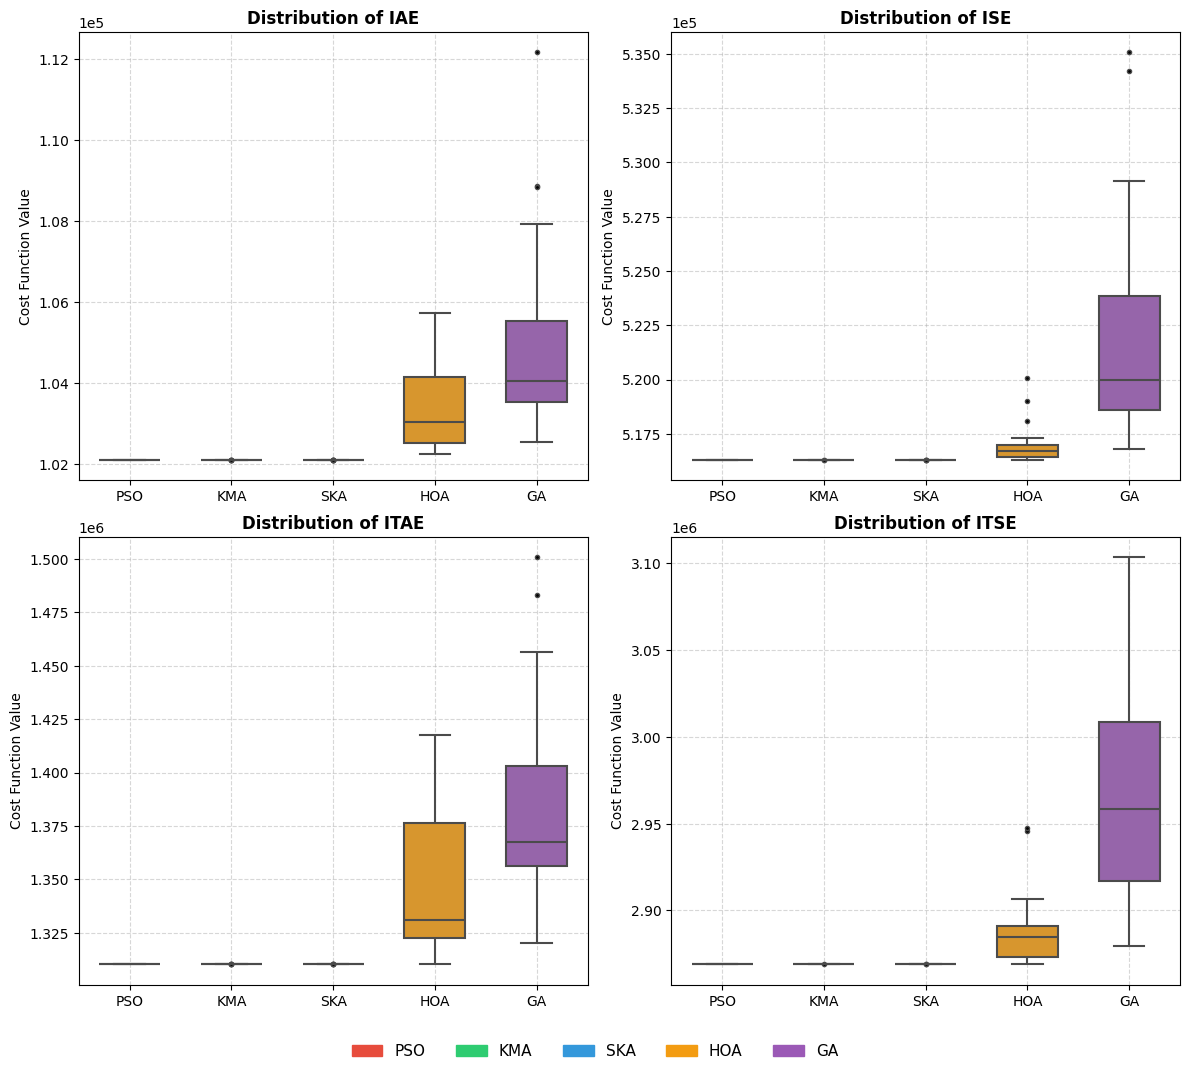

Gambar 'data/statistics/stability/boxplot_comparison_consistent_colors.png' berhasil disimpan!


In [16]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import matplotlib.patches as mpatches # Diperlukan untuk Custom Legend

# 1. Load Data
# Pastikan file .pkl ada di direktori yang sama
if os.path.exists('data/aggregated/all_best_fitnesses.pkl'):
    with open('data/aggregated/all_best_fitnesses.pkl', 'rb') as f:
        data = pickle.load(f)
else:
    print("[ERROR] File 'data/aggregated/all_best_fitnesses.pkl' tidak ditemukan.")
    # Stop execution or create dummy data here if needed
    data = {} 

# 2. Reformat Data untuk Plotting
plot_data = []
algos = ['pso', 'kma', 'ska', 'hoa', 'ga']
objs = ['iae', 'ise', 'itae', 'itse']

for obj in objs:
    for algo in algos:
        if algo in data.get(obj, {}):
            values = data[obj][algo]
            for v in values:
                plot_data.append({
                    'Objective': obj.upper(),
                    'Algorithm': algo.upper(),
                    'Fitness': v
                })

df_plot = pd.DataFrame(plot_data)

# 3. Setup Gambar (Grid 2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 11), sharex=False) # Tinggi ditambah sedikit untuk legend
axes = axes.flatten()

# --- UPDATE WARNA (Sesuai Convergence Plot) ---
# Skema warna ini SAMA PERSIS dengan plot konvergensi sebelumnya
my_pal = {
    "PSO": "#e74c3c",  # Merah
    "KMA": "#2ecc71",  # Hijau
    "SKA": "#3498db",  # Biru
    "HOA": "#f39c12",  # Orange (Sebelumnya abu-abu)
    "GA":  "#9b59b6"   # Ungu (Sebelumnya abu-abu)
}

for i, obj in enumerate(objs):
    ax = axes[i]
    # Filter data per objective
    subset = df_plot[df_plot['Objective'] == obj.upper()]
    
    if not subset.empty:
        # Gambar Boxplot
        sns.boxplot(
            x='Algorithm', 
            y='Fitness', 
            data=subset, 
            ax=ax, 
            palette=my_pal, 
            width=0.6, 
            linewidth=1.5,
            flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 3}
        )
        
    # Judul & Label
    ax.set_title(f'Distribution of {obj.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Cost Function Value')
    
    # Format Scientific Notation
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.grid(True, linestyle='--', alpha=0.5)

# 4. Tambahkan Legend Gabungan (Agar sesuai dengan Convergence Plot)
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in my_pal.items()]
fig.legend(
    handles=legend_patches,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02),
    ncol=5, 
    fontsize=11,
    frameon=False
)

filepath = 'data/statistics/stability/boxplot_comparison_consistent_colors.png'
directory = os.path.dirname(filepath)
os.makedirs(directory, exist_ok=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.savefig(filepath, dpi=300)
plt.show()
print("Gambar 'data/statistics/stability/boxplot_comparison_consistent_colors.png' berhasil disimpan!")

# Full Best Fitness Plot

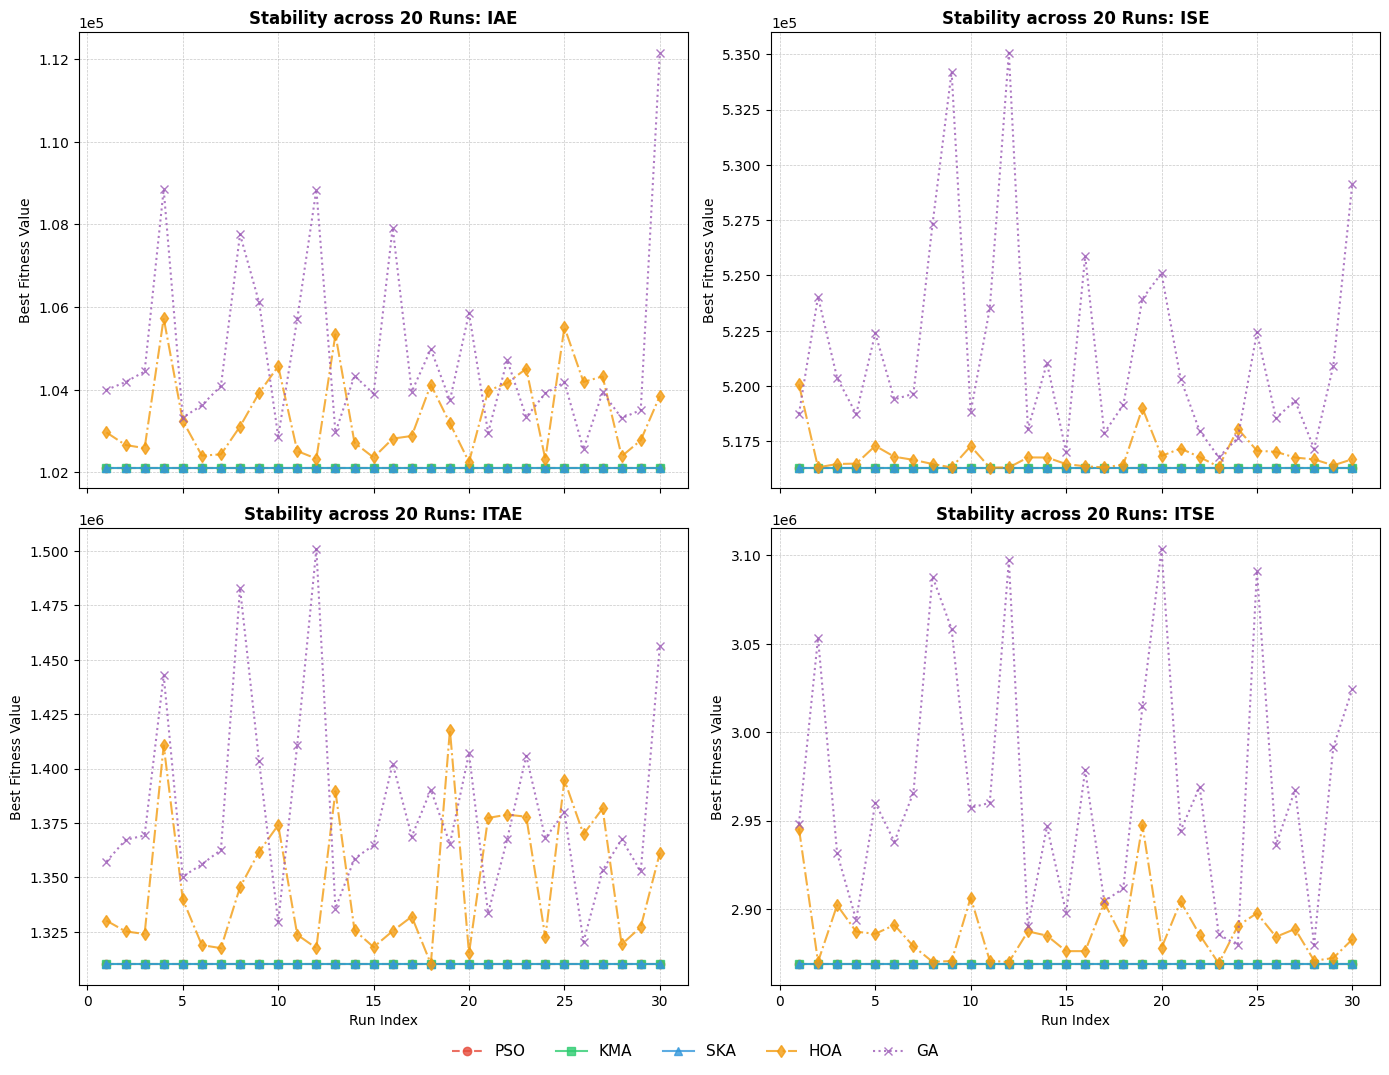

Grafik 'data/statistics/stability/full_fitness_stability_plot_colored.png' berhasil dibuat!


In [17]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Load Data
file_path = 'data/aggregated/all_best_fitnesses.pkl'

if os.path.exists(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
else:
    print("[ERROR] File pickle tidak ditemukan.")
    # Dummy data untuk testing jika file tidak ada
    data = {}

# 2. Setup Plot Configuration
objectives = ['iae', 'ise', 'itae', 'itse']
# algos = ['pso', 'kma', 'ska', 'hoa', 'ga'] # Urutan legend
algos = ['pso', 'kma', 'ska', 'hoa', 'ga']

# --- UPDATE WARNA & STYLE (Sesuai Convergence Plot) ---
# KMA (Hijau), SKA (Biru), PSO (Merah), HOA (Orange), GA (Ungu)
styles = {
    'pso': {'color': '#e74c3c', 'marker': 'o', 'label': 'PSO', 'ls': '--'},    # Red
    'kma': {'color': '#2ecc71', 'marker': 's', 'label': 'KMA', 'ls': '-'},     # Green
    'ska': {'color': '#3498db', 'marker': '^', 'label': 'SKA', 'ls': '-'},     # Blue
    'hoa': {'color': '#f39c12', 'marker': 'd', 'label': 'HOA', 'ls': '-.'},   # Orange
    'ga':  {'color': '#9b59b6', 'marker': 'x', 'label': 'GA',  'ls': ':'}      # Purple
}

# 3. Create Subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True) # Height ditambah dikit buat legend
axes = axes.flatten()

# List untuk menyimpan handle legend (biar rapi)
legend_handles = []
legend_labels = []

for i, obj in enumerate(objectives):
    ax = axes[i]
    
    # Ambil data per objective
    obj_data = data.get(obj, {})
    
    for algo in algos:
        if algo in obj_data:
            y_values = obj_data[algo]
            x_values = np.arange(1, len(y_values) + 1) # Run 1 sampai 20
            
            # Plot Line Chart
            line, = ax.plot(x_values, y_values, 
                    color=styles[algo]['color'], 
                    marker=styles[algo]['marker'],
                    linestyle=styles[algo]['ls'],
                    linewidth=1.5,
                    markersize=6,
                    label=styles[algo]['label'],
                    alpha=0.8)
            
            # Simpan handle untuk legend (hanya dari plot pertama biar tidak duplikat)
            if i == 0:
                legend_handles.append(line)
                legend_labels.append(styles[algo]['label'])

    # Kosmetik Grafik
    ax.set_title(f'Stability across 20 Runs: {obj.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Best Fitness Value')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Mengatur Y-Axis ke Scientific Notation biar rapi
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Label X-Axis untuk baris bawah saja
axes[2].set_xlabel('Run Index')
axes[3].set_xlabel('Run Index')

# 4. Tambahkan Legend Gabungan di Bawah
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02),
    ncol=5, 
    fontsize=11,
    frameon=False
)

# Layout Adjustment
plt.tight_layout()
plt.subplots_adjust(bottom=0.1) # Beri ruang kosong di bawah untuk legend
plt.savefig('data/statistics/stability/full_fitness_stability_plot_colored.png', dpi=300) # Simpan gambar
plt.show()

print("Grafik 'data/statistics/stability/full_fitness_stability_plot_colored.png' berhasil dibuat!")

# Objective Function & Time Response Correlation
Although objective functions such as IAE, ISE, ITAE, and ITSE are widely used to guide controller optimization, their physical relevance to time-domain performance characteristics is often implicitly assumed. To explicitly investigate this relationship, correlation analysis was conducted between the objective function values and key time-domain response metrics, including rise time, overshoot, settling time, and steady-state error.

Since the analyzed data do not necessarily follow a normal distribution and may exhibit non-linear monotonic relationships, Spearman’s rank correlation coefficient was employed. This analysis aims to reveal how effectively each objective function reflects the underlying dynamic behavior of the ACC system, thereby providing insight into their suitability for safety- and efficiency-oriented controller design.

# Time Response Analysis

## Variable and Utilities Preparation

In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  # Tambahan untuk membaca CSV
import ast           # Tambahan untuk konversi string "[1,2,3]" jadi list asli
from benchmarks.sisken_prastiyanto import error_synthesizer
from core.physics import VehiclePhysics
from core.utils import iae, ise, itae, itse
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import os

# =========================================================================
# --- MEMBACA PARAMS DARI CSV SECARA DINAMIS ---
# =========================================================================
csv_path = "data/statistics/statistical_report.csv"
params = {}

if os.path.exists(csv_path):
    print(f"Loading best solutions from {csv_path}...")
    df_stats = pd.read_csv(csv_path)
    
    for index, row in df_stats.iterrows():
        obj_name = str(row["Objective"]).lower()
        algo_name = str(row["Algorithm"]).lower()
        
        # Mengubah string list dari CSV "[10.0, 0.42, -10.0]" ke list float betulan
        try:
            best_solution_str = row["Best Solution Vector"]
            best_sol_list = ast.literal_eval(best_solution_str)
        except (ValueError, SyntaxError) as e:
            print(f"Error parsing solution for {obj_name}-{algo_name}: {e}")
            continue
            
        # Memasukkan ke dalam dictionary
        if obj_name not in params:
            params[obj_name] = {}
        
        params[obj_name][algo_name] = best_sol_list
else:
    print(f"File {csv_path} tidak ditemukan! Menggunakan param default/kosong.")
    # Kamu bisa mengembalikan dictionary default di sini jika file belum ada
# =========================================================================



Loading best solutions from data/statistics/statistical_report.csv...


# Time Response Cruise Control Analysis

### Control System Utilities

In [ ]:
def step_response_metrics(time, y, ref, y0=None, steady_window=2.0, tol=0.02, rise_frac=(0.1, 0.9)):
    """
    Compute step-response metrics for a step-to-constant reference.
    - time: array (seconds)
    - y: measured signal (e.g., v_ego)
    - ref: target setpoint (e.g., 25 m/s)
    - y0: initial value (if None uses y[0])
    - steady_window: seconds from the end used to estimate steady-state value (mean of last window)
    - tol: settling band ratio, e.g., 0.02 = 2%
    - rise_frac: (low, high) fractions of step amplitude (default 10%-90%)

    Returns dict with:
      y0, y_ss, ss_error,
      peak_value, peak_time,
      overshoot, overshoot_pct,
      rise_time, t10, t90,
      settling_time
    """
    t = np.asarray(time, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0:
        raise ValueError("Empty time series.")

    if y0 is None:
        y0 = float(y[0])

    # steady-state estimate from last steady_window seconds (mean)
    t_end = float(t[-1])
    if steady_window is not None and steady_window > 0:
        mask = t >= (t_end - steady_window)
        y_ss = float(np.mean(y[mask])) if np.any(mask) else float(y[-1])
    else:
        y_ss = float(y[-1])

    ss_error = float(ref - y_ss)

    # Determine step direction by comparing ref vs y0
    rising = ref >= y0
    direction = "rising" if rising else "falling"

    # Peak / extreme
    if rising:
        peak_idx = int(np.argmax(y))
        peak_value = float(y[peak_idx])
        peak_time = float(t[peak_idx])
        overshoot = max(0.0, peak_value - ref)
    else:
        peak_idx = int(np.argmin(y))
        peak_value = float(y[peak_idx])
        peak_time = float(t[peak_idx])
        overshoot = max(0.0, ref - peak_value)

    step_amp = abs(ref - y0)
    overshoot_pct = float(100.0 * overshoot / step_amp) if step_amp > 0 else 0.0

    # Rise time 10%-90% of step amplitude (based on y0 -> ref)
    low_f, high_f = rise_frac
    low_level = y0 + (ref - y0) * low_f
    high_level = y0 + (ref - y0) * high_f

    t10 = _first_crossing_time(t, y, low_level, direction=direction)
    t90 = _first_crossing_time(t, y, high_level, direction=direction)
    rise_time = (t90 - t10) if (t10 is not None and t90 is not None and t90 >= t10) else None

    # Settling time relative to ref (common in control)
    ts = settling_time(t, y, y_final=ref, tol=tol, start_time=t10)

    return {
        "y0": float(y0),
        "y_ss": float(y_ss),
        "steady_state_error": ss_error,

        "peak_value": peak_value,
        "peak_time": peak_time,

        "overshoot": float(overshoot),
        "overshoot_pct": float(overshoot_pct),

        "t10": t10,
        "t90": t90,
        "rise_time": float(rise_time) if rise_time is not None else None,

        "settling_time": ts,
        "ref": float(ref),
        "tol": float(tol),
    }

objectives = {"iae": iae, "ise": ise, "itae": itae, "itse": itse}

def compute_jerk(a_ego, dt):
    a = np.array(a_ego)
    jerk = np.diff(a) / dt
    return np.concatenate([[0], jerk])  # align length

def compute_ttc(d_actual, v_ego, v_lead, eps=1e-9):
    """
    TTC definition (classic):
    TTC = d / (v_ego - v_lead) when v_ego > v_lead and d > 0
    otherwise TTC = inf
    """
    if d_actual <= 0:
        return 0.0  # already collided / overlap (or negative distance)
    dv = v_ego - v_lead
    if dv <= eps:
        return math.inf
    return d_actual / dv

def _interp_crossing_time(t, y, level, idx):
    """
    Linear interpolation to estimate crossing time between idx-1 and idx
    where y crosses 'level'. Assumes (y[idx-1]-level) and (y[idx]-level) have opposite signs.
    """
    t0, t1 = t[idx - 1], t[idx]
    y0, y1 = y[idx - 1], y[idx]
    if y1 == y0:
        return float(t1)
    alpha = (level - y0) / (y1 - y0)
    return float(t0 + alpha * (t1 - t0))

def _first_crossing_time(t, y, level, direction="auto"):
    """
    Returns the first time y crosses 'level' (with interpolation).
    direction:
      - "rising": crossing from below to above
      - "falling": crossing from above to below
      - "auto": decide from start/end trend
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) < 2:
        return None

    if direction == "auto":
        direction = "rising" if (y[-1] >= y[0]) else "falling"

    if direction == "rising":
        cond = (y[:-1] < level) & (y[1:] >= level)
    else:
        cond = (y[:-1] > level) & (y[1:] <= level)

    idxs = np.where(cond)[0]
    if idxs.size == 0:
        return None

    i = int(idxs[0] + 1)
    return _interp_crossing_time(t, y, level, i)

def settling_time(t, y, y_final, tol=0.02, start_time=None):
    """
    Settling time: earliest time after which y stays within +/- tol*|y_final|
    (or absolute band if y_final == 0) for the remainder.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) == 0:
        return None

    if start_time is not None:
        mask = t >= start_time
        t2, y2 = t[mask], y[mask]
    else:
        t2, y2 = t, y

    if len(t2) == 0:
        return None

    band = tol * abs(y_final) if y_final != 0 else tol
    outside = np.abs(y2 - y_final) > band

    if not np.any(outside):
        return float(t2[0])  # already settled at start

    last_outside_idx = int(np.where(outside)[0][-1])
    if last_outside_idx == len(t2) - 1:
        return None  # never settles within horizon
    return float(t2[last_outside_idx + 1])

def plot_velocity_compare(
    obj_name,
    histories_by_algo,
    metrics_by_algo,
    outdir="data/time_response/cruise_control",
    ref=25.0,
    show_metrics_in_legend=True,
    zoom_xlim=(0.85, 1.10), 
    zoom_ylim=(24.90, 25.02),
    inset_size=("55%", "50%"),
    inset_loc="center right"
):
    os.makedirs(outdir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Style Dictionary (Warna konsisten)
    styles = {
        'pso': {'color': '#e74c3c', 'ls': '-', 'lw': 2.0, 'label': 'PSO'},   # Red
        'kma': {'color': '#2ecc71', 'ls': '-',  'lw': 2.0, 'label': 'KMA'},    # Green
        'ska': {'color': '#3498db', 'ls': '-',  'lw': 2.0, 'label': 'SKA'},    # Blue
        'hoa': {'color': '#f39c12', 'ls': '-.', 'lw': 2.0, 'label': 'HOA'},    # Orange
        'ga' : {'color': '#9b59b6', 'ls': '-',  'lw': 2.0, 'label': 'GA'},     # Purple
    }

    # ============ MAIN PLOT ============
    for algo, hist in histories_by_algo.items():
        t = np.asarray(hist["time"])
        v = np.asarray(hist["v_ego"])

        # --- LOGIC LABEL LEGEND BARU ---
        if show_metrics_in_legend:
            m = metrics_by_algo[algo]
            mp = m.get("overshoot", None)
            tr = m.get("rise_time", None)
            ts = m.get("settling_time", None)
            
            # Hitung Steady State Error (Ess) secara manual dari data terakhir
            final_v = v[-1]
            ess = abs(ref - final_v)

            mp_pct = (mp * 100.0) if (mp is not None and np.isfinite(mp)) else None
            
            label = f"{algo.upper()}"
        else:
            label = algo.upper()

        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1.8, 'label': algo.upper()})
        ax.plot(t, v, linewidth=st['lw'], linestyle=st['ls'], color=st['color'], label=label)

    ax.axhline(ref, linestyle="--", linewidth=1.5, label=f"Reference = {ref:.1f} m/s")
    ax.set_title(f"Speed Step Response Comparison — Objective: {obj_name.upper()}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Ego speed (m/s)")
    ax.grid(True)

    # Legend ditaruh di kiri bawah agak naik dikit
    leg = ax.legend(
        loc="lower left",
        bbox_to_anchor=(0.1, 0.08), # Naikkan sedikit (0.02 -> 0.08) biar gak kena sumbu X
        fontsize=8,
        frameon=True,
        framealpha=0.9
    )
    leg.set_zorder(30)

    # # ============ INSET PLOT (MANUAL) ============
    axins = inset_axes(ax, width=inset_size[0], height=inset_size[1],
                        loc=inset_loc, borderpad=1.0) 
    
    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 2.0})
        axins.plot(hist["time"], hist["v_ego"], linewidth=st['lw'], linestyle=st['ls'], color=st['color']) 
    
    axins.axhline(ref, linestyle="--", linewidth=1.5, color='#1f77b4', alpha=0.9)
    
    # --- MANUAL LIMITS ---
    axins.set_xlim(*zoom_xlim)
    axins.set_ylim(*zoom_ylim)
    
    axins.grid(True)
    axins.tick_params(axis='both', which='major', labelsize=8)

    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", alpha=0.7)

    plt.tight_layout()
    outpath = os.path.join(outdir, f"speed_compare_{obj_name.lower()}_zoom_manual.png")
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=250)
    plt.close(fig)

def lean_simulate_system(params, obj_fun, return_history=False, 
                         sim_time=60, theta_angle=0, vehicle_mass=1500, 
                         rolling_resistance=0.06, v_ref_init=25):
    """
    obj_fun is now a FUNCTION, not a string.
    It must accept (err, time) or (err) depending on the metric.
    """
    physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)

    verr_gain, vx_gain, xerr_gain = params
    theta = 0
    vset = v_ref_init or 25.0
    xego, vego, aego = 0, 22, 0
    xlead, vlead, alead = 60, 22, 0
    ddef, Tg = 20, 1.2
    Ts = 1 / 60
    obj_val = 0
    simulation_steps = int(sim_time / Ts)

    history = {
        "time": [],
        "v_ego": [],
        "v_ref": [],
        "u": [],
    }

    for i in range(simulation_steps):
        t = i * Ts

        # Compute errors
        dactual = xlead - xego
        dsafe   = ddef + Tg * vego

        vrel    = vlead - vego
        derr    = dsafe - dactual
        verr    = vset - vego

        # Controller
        u_v = verr_gain * verr
        # u_x = vrel * vx_gain + xerr_gain * derr

        # LOGIKA SWITCHING YANG LEBIH LOGIS
        u = u_v

        # Update ego car
        vego, aego, Ft = physics.step(vego, u, Ts)
        xego += vego * Ts

        c_nrg   = max(0, Ft)
        err     = error_synthesizer(derr, verr, 0, t, obj_fun)
        obj_val += err

        history["time"].append(t)
        history["v_ego"].append(vego)
        history["v_ref"].append(vset)
        history["u"].append(u)

    return history

C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\4164019657.py:267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


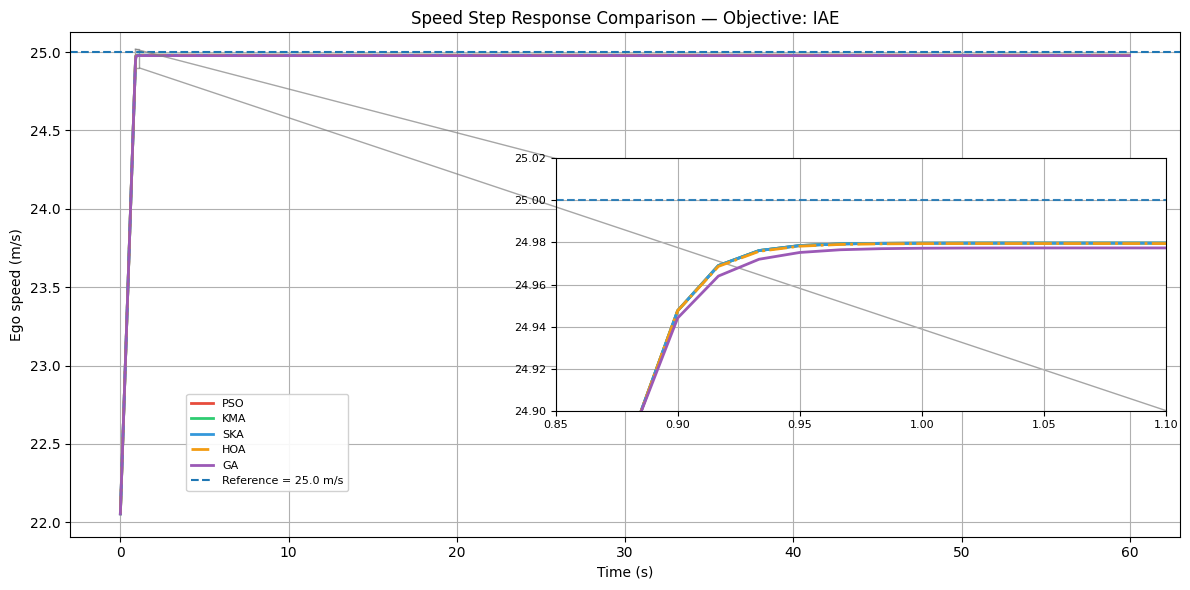


=== Objective IAE — time-domain summary (sorted by ts) ===
 PSO | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 KMA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 SKA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 HOA | tr=0.733 | tp=1.383 | ts=0.917 | Mp%=0.000 | ess=0.0205
  GA | tr=0.733 | tp=1.450 | ts=0.917 | Mp%=0.000 | ess=0.0226


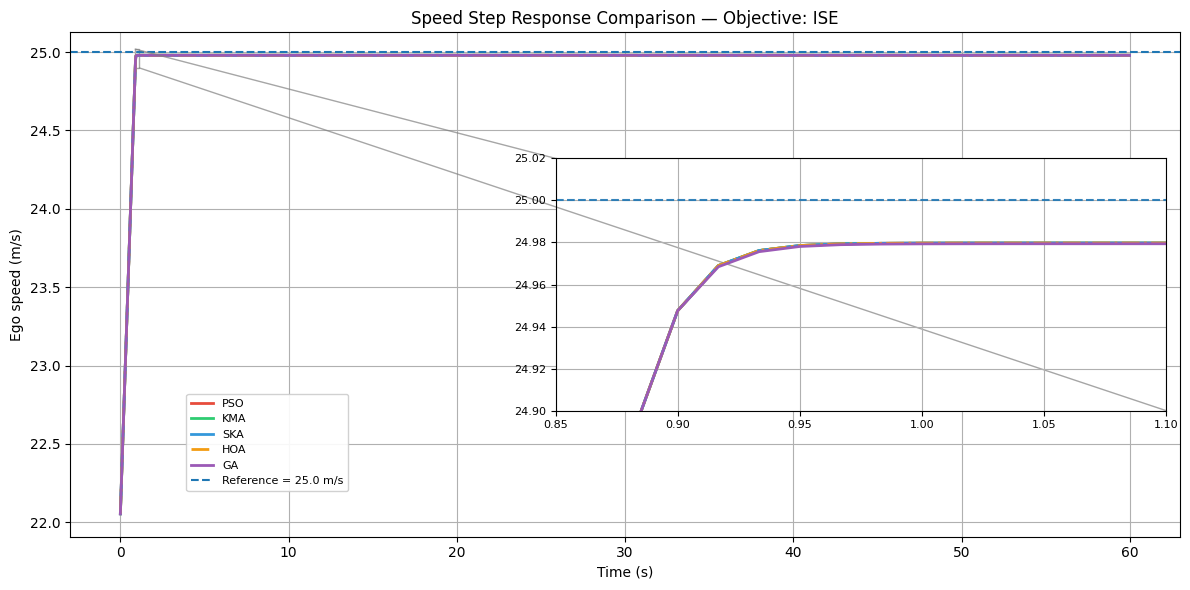


=== Objective ISE — time-domain summary (sorted by ts) ===
 PSO | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 KMA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 SKA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 HOA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
  GA | tr=0.733 | tp=1.383 | ts=0.917 | Mp%=0.000 | ess=0.0206


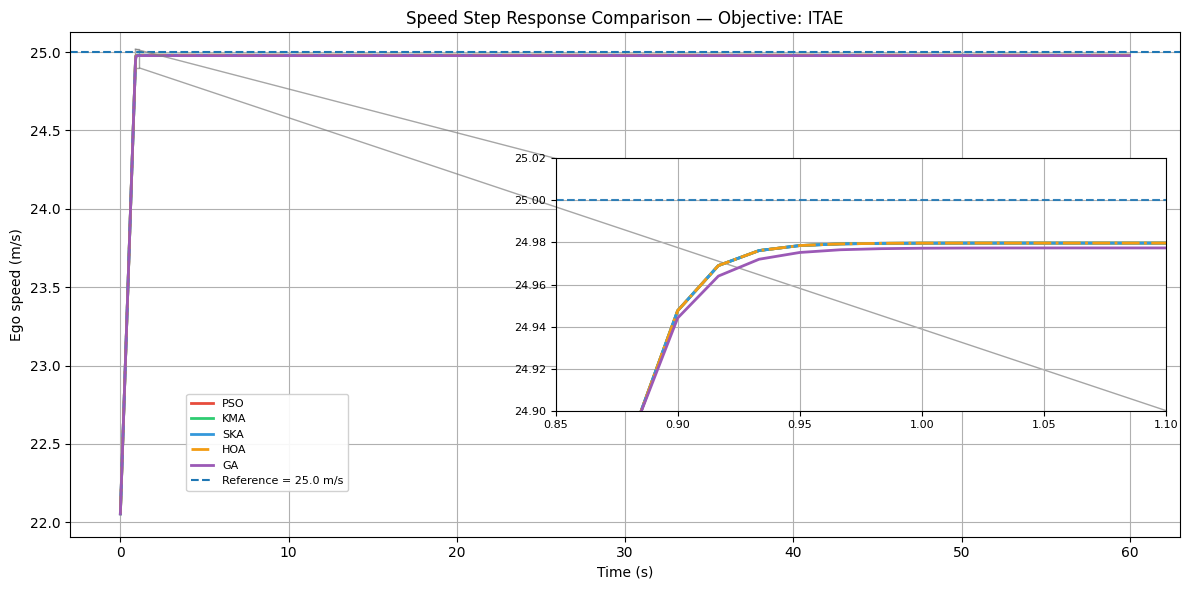


=== Objective ITAE — time-domain summary (sorted by ts) ===
 PSO | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 KMA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 SKA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 HOA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
  GA | tr=0.733 | tp=1.450 | ts=0.917 | Mp%=0.000 | ess=0.0226


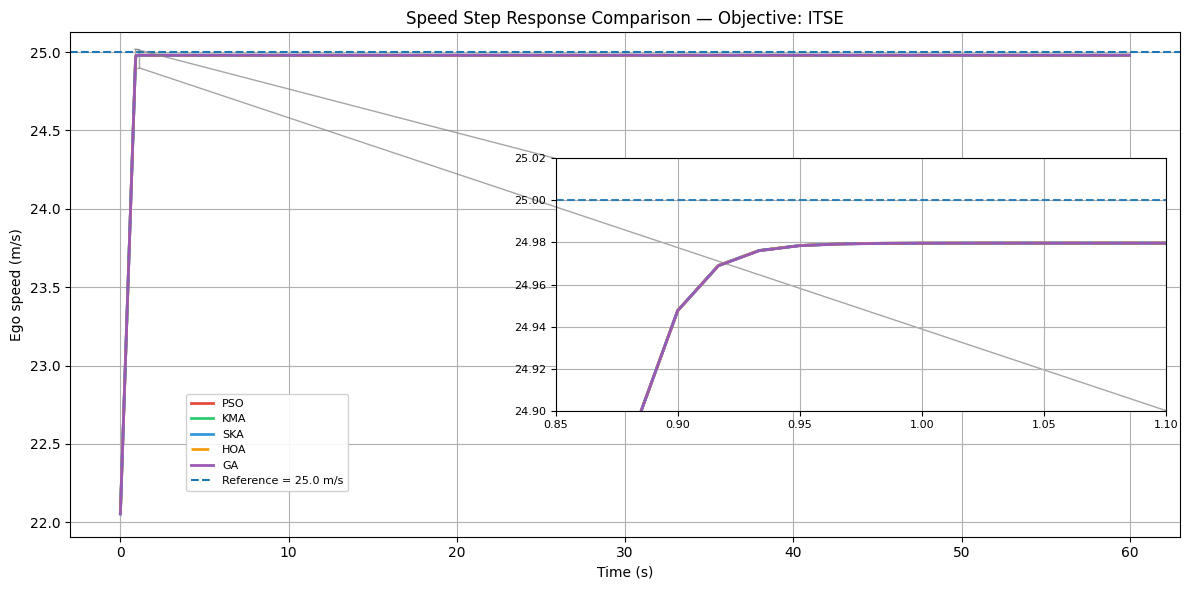


=== Objective ITSE — time-domain summary (sorted by ts) ===
 PSO | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 KMA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 SKA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
 HOA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203
  GA | tr=0.733 | tp=1.367 | ts=0.917 | Mp%=0.000 | ess=0.0203


In [20]:
def run_all(params, objectives, ref=25.0, steady_window=2.0, tol=0.001, steady_state_plot=False):
    """
    tol=0.02 means 2% settling band (lebih standar).
    Kamu sebelumnya pakai 0.0002 (0.02%) itu super ketat dan sering bikin ts jadi aneh/None.
    """
    if not params:
        print("Params kosong. Eksekusi dihentikan.")
        return {}, {}
        
    all_histories = {}
    all_metrics = {}

    for obj_name, algo_params in params.items():
        histories_by_algo = {}
        metrics_by_algo = {}

        for algo_name, param_vec in algo_params.items():
            # Pastikan cappiello_iae bisa diimport di level ini atau ganti logic-nya bila perlu
            from core.utils import cappiello_iae 
            
            # Memanggil fungsi simulasi dengan param_vec
            hist = lean_simulate_system(param_vec, cappiello_iae, v_ref_init=ref)
            histories_by_algo[algo_name] = hist

            metrics_by_algo[algo_name] = step_response_metrics(
                time=hist["time"],
                y=hist["v_ego"],
                ref=ref,
                steady_window=steady_window,
                tol=tol,
            )

        all_histories[obj_name] = histories_by_algo
        all_metrics[obj_name] = metrics_by_algo

        # One plot per objective with all algos
        plot_velocity_compare(obj_name, histories_by_algo, metrics_by_algo, ref=ref)

        # Optional: print a compact summary (sorted by settling time)
        rows = []
        for algo, m in metrics_by_algo.items():
            rows.append((algo.upper(), m.get("rise_time"), m.get("peak_time"), m.get("settling_time"), m.get("overshoot"), m.get("steady_state_error")))
        rows.sort(key=lambda x: (np.inf if x[3] is None else x[3]))

        print(f"\n=== Objective {obj_name.upper()} — time-domain summary (sorted by ts) ===")
        for r in rows:
            algo, tr, tp, ts, mp, ess = r
            mp_pct = (mp * 100.0) if mp is not None else None
            
            # Handle format print agar rapi jika nilainya None
            ts_str = f"{ts:.3f}" if ts is not None else "None "
            mp_pct_str = f"{mp_pct:.3f}" if mp_pct is not None else "None "
            
            print(f"{algo:>4s} | tr={tr:.3f} | tp={tp:.3f} | ts={ts_str} | Mp%={mp_pct_str} | ess={ess:.4f}")

    return all_histories, all_metrics

# Jalankan simulasi jika params berhasil diload dari CSV
if params:
    run_all(params, objectives, ref=25.0, steady_window=2.0, tol=0.002, steady_state_plot=False)

# TTC-based Distance Control

### Car Following Utilities

In [21]:
from core.physics import VehiclePhysics
from core.utils import sin_angle, iae, ise, itae, itse, cappiello_iae, cappiello_ise, cappiello_itae, cappiello_itse
from benchmarks.sisken_prastiyanto import lean_simulate_system as prastiyanto_sim
import math
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_ttc_compare_for_objective(obj_name, histories_by_algo, outpath,
                                   ttc_threshold=3.0, ttc_max_plot=None):
    """
    Modified: No metrics in title. Cleaner plot.
    """
    any_hist = next(iter(histories_by_algo.values()))
    time = np.array(any_hist["time"])

    plt.figure(figsize=(12, 6)) # Adjusted size slightly for paper fit
    
    # Style Dictionary (Warna konsisten)
    styles = {
        'pso': {'color': '#e74c3c', 'ls': '-', 'lw': 2.0},  # Red
        'kma': {'color': '#2ecc71', 'ls': '-',  'lw': 2.0},   # Green
        'ska': {'color': '#3498db', 'ls': '-',  'lw': 2.0},   # Blue
        'hoa': {'color': '#f39c12', 'ls': '-.', 'lw': 2.0},   # Orange
        'ga' : {'color': '#9b59b6', 'ls': '-',  'lw': 2.0},   # Purple
    }

    # Plot each algorithm
    for algo, hist in histories_by_algo.items():
        ttc = np.array(hist["ttc"], dtype=float)

        if ttc_max_plot is not None:
            ttc = np.where(np.isfinite(ttc), np.minimum(ttc, ttc_max_plot), ttc_max_plot)

        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1.5})
        plt.plot(time, ttc, linewidth=st['lw'], linestyle=st['ls'], color=st['color'], label=algo.upper())

    # Critical Threshold Line (Red & Dashed for emphasis)
    plt.axhline(ttc_threshold, color='red', linestyle="--", linewidth=1.5, 
                label=f"Critical Threshold ({ttc_threshold}s)")

    # Judul Bersih
    plt.title(f"Time-to-Collision (TTC) Comparison — Objective: {obj_name.upper()}")
    plt.xlabel("Time (s)")
    plt.ylabel("TTC (s)")
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    
    # Legend placement optimization
    plt.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=300) # High DPI for paper
    plt.close()

# --- FUNGSI PLOT 2: MOTION PROFILE (Baru) ---
def plot_motion_profiles(obj_name, histories_by_algo, outpath):
    """
    Plot 3 Subplots: 
    1. Relative Distance (Headway)
    2. Velocity Profile
    3. Acceleration Profile
    """
    any_hist = next(iter(histories_by_algo.values()))
    time = np.array(any_hist["time"])
    
    # Ambil data Lead Vehicle (Cukup ambil dari salah satu algo, karena sama semua)
    v_lead = np.array(any_hist["v_lead"])
    a_lead = np.array(any_hist["a_lead"])

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # Styles Dictionary (Sama dengan TTC)
    styles = {
        'pso': {'color': '#e74c3c', 'ls': '-', 'lw': 1.5, 'zorder': 3},  # Red
        'kma': {'color': '#2ecc71', 'ls': '-', 'lw': 1.5, 'zorder': 5},   # Green
        'ska': {'color': '#3498db', 'ls': '-', 'lw': 1.5, 'zorder': 4},   # Blue
        'hoa': {'color': '#f39c12', 'ls': '-.', 'lw': 1.5, 'zorder': 2},  # Orange
        'ga' : {'color': '#9b59b6', 'ls': '-', 'lw': 1.5, 'zorder': 1}    # Purple
    }
    # --- SUBPLOT 1: RELATIVE DISTANCE & SAFE DISTANCE ---
    ax = axes[0]
    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
        lbl = algo.upper()
        
        dist = np.array(hist["dist"])
        dsafe = np.array(hist["d_safe"]) 
        
        # Plot Actual Distance (Solid Line with Algo Color)
        ax.plot(time, dist, color=st['color'], ls=st['ls'], lw=st['lw'], label=lbl, zorder=st['zorder'])
        
        # Plot Safe Distance (BLACK DASHED LINE - Like Lead Vehicle)
        # alpha=0.4 agar tidak terlalu dominan jika menumpuk
        ax.plot(time, dsafe, color='black', ls='--', lw=1.2, alpha=0.4, zorder=1)
    
    # Legend Entry Khusus untuk Safe Distance (Black Dashed)
    ax.plot([], [], color='black', ls='--', label='Safe Dist ($d_{safe}$)')

    ax.set_ylabel("Distance (m)")
    ax.set_title(f"Motion Profile Analysis — {obj_name.upper()}\n(a) Inter-vehicle Distance vs Safe Distance")
    ax.grid(True, linestyle='--', alpha=0.6)
    # Menampilkan legend (Kolom ditambah agar muat)
    ax.legend(loc="upper left", fontsize='small', ncol=3)


    # --- SUBPLOT 2: VELOCITY ---
    ax = axes[1]
    # Plot Lead Velocity Reference
    ax.plot(time, v_lead, 'k--', linewidth=2.0, label="Lead Vehicle", alpha=0.7)
    
    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
        vel = np.array(hist["v_ego"])
        ax.plot(time, vel, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=st['zorder']) # No label to save space
        
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title("(b) Velocity Profile")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="upper right", fontsize='small')

    # --- SUBPLOT 3: ACCELERATION ---
    ax = axes[2]
    # Plot Lead Acceleration Reference
    ax.plot(time, a_lead, 'k--', linewidth=1.5, label="Lead Accel", alpha=0.5)

    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
        acc = np.array(hist["a_ego"])
        ax.plot(time, acc, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=st['zorder'])

    ax.set_ylabel("Acceleration (m/s²)")
    ax.set_xlabel("Time (s)")
    ax.set_title("(c) Acceleration Profile")
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=300)
    plt.close()


### Car Following Execution

In [22]:
# =========================
# RUN MAIN
# =========================
TTC_THRESHOLD = 1.5 
TTC_MAX_PLOT = 100.0
GLOBAL_SEED = 123 

directory = "data/time_response/car_following"
os.makedirs(directory, exist_ok=True)

objectives = {
    "iae": cappiello_iae, 
    "ise": cappiello_ise, 
    "itae": cappiello_itae, 
    "itse": cappiello_itse
}

print("Memulai Generasi Grafik TTC dan Motion Profile...")

for obj_name, algo_params in params.items():
    histories = {}
    print(f"Processing {obj_name.upper()}...")
    
    for algo_name, param_vec in algo_params.items():
        # Jalankan Simulasi
        _, histories[algo_name] = prastiyanto_sim(
            param_vec,
            objectives[obj_name],
            return_history=True,
            ttc_threshold=TTC_THRESHOLD,
        )

    # 1. Plot TTC 
    plot_ttc_compare_for_objective(
        obj_name,
        histories_by_algo=histories,
        outpath=f"{directory}/ttc/ttc_compare_{obj_name}.png",
        ttc_threshold=TTC_THRESHOLD,
        ttc_max_plot=TTC_MAX_PLOT
    )
    
    # 2. Plot Motion Profile 
    plot_motion_profiles(
        obj_name,
        histories_by_algo=histories,
        outpath=f"{directory}/motion/motion_profile_{obj_name}.png"
    )

print("Done! Check " + directory + " folder.")

Memulai Generasi Grafik TTC dan Motion Profile...
Processing IAE...
Processing ISE...
Processing ITAE...
Processing ITSE...
Done! Check data/time_response/car_following folder.


# Robustness Analysis

### Robustness Test Utilities

In [55]:
from core.physics import VehiclePhysics
from core.utils import sin_angle, iae, ise, itae, itse
from benchmarks.sisken_prastiyanto import lean_simulate_system as prastiyanto_sim
import math
import numpy as np
import matplotlib.pyplot as plt
import os
import csv

# --- 1. DEFINISI SCENARIOS ---
SCENARIOS = [
    {"id": "S0", "desc": "Normal", "theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S1", "desc": "Mass+10%", "theta_angle": 0,  "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S2", "desc": "Mass-10%", "theta_angle": 0,  "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S3", "desc": "Res+20%", "theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.072},
    {"id": "S4", "desc": "Up Normal", "theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S5", "desc": "Up Mass+", "theta_angle": 10, "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S6", "desc": "Up Mass-", "theta_angle": 10, "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S7", "desc": "Up Res+", "theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.072},
    {"id": "S8", "desc": "Down Normal", "theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S9", "desc": "Down Mass+", "theta_angle": -10, "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S10", "desc": "Down Mass-", "theta_angle": -10, "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S11", "desc": "Down Res+", "theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.072},
]

objectives = {
    "iae": cappiello_iae, 
    "ise": cappiello_ise, 
    "itae": cappiello_itae, 
    "itse": cappiello_itse
}

# --- 3. CORE SIMULATION ---
def compute_ttc(d_actual, v_ego, v_lead, eps=1e-9):
    if d_actual <= 0: return 0.0
    dv = v_ego - v_lead
    if dv <= eps: return math.inf
    return d_actual / dv

# --- 4. NEW: UNIFIED PLOTTING FUNCTION ---
def plot_combined_analysis(obj_name, histories, outpath, scenario_desc, ttc_threshold=1.5):
    """
    Membuat 1 Gambar dengan 4 Subplot:
    1. TTC (Safety)
    2. Distance (Headway)
    3. Velocity (Tracking)
    4. Acceleration (Comfort/Jerk)
    """
    any_hist = next(iter(histories.values()))
    time = np.array(any_hist["time"])
    v_lead = np.array(any_hist["v_lead"])
    a_lead = np.array(any_hist["a_lead"])

    # Setup 4 baris, share X axis
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    
    # Style Dictionary
    styles = {
        'pso': {'c': '#e74c3c', 'ls': '-', 'lw': 1.5, 'z': 3}, # Red
        'kma': {'c': '#2ecc71', 'ls': '-', 'lw': 1.5, 'z': 5},  # Green
        'ska': {'c': '#3498db', 'ls': '-', 'lw': 1.5, 'z': 4},  # Blue
        'hoa': {'c': '#f39c12', 'ls': '-.', 'lw': 1.5, 'z': 2}, # Orange
        'ga' : {'c': '#9b59b6', 'ls': '-',  'lw': 1.5, 'z': 1}  # Purple
    }

    # --- SUBPLOT 1: TTC ---
    ax = axes[0]
    for algo, hist in histories.items():
        ttc = np.array(hist["ttc"], dtype=float)
        # Cap infinite values for plotting clarity
        ttc = np.where(np.isfinite(ttc), np.minimum(ttc, 20.0), 20.0)
        
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        lbl = algo.upper() + (" (Proposed)" if algo.lower() in ['kma', 'ska'] else "")
        ax.plot(time, ttc, color=st['c'], ls=st['ls'], lw=st['lw'], label=lbl, zorder=st['z'])
    
    ax.axhline(ttc_threshold, color='red', ls='--', lw=1.5, label=f"Critical Threshold ({ttc_threshold}s)")
    ax.set_ylabel("TTC (s)")
    ax.set_ylim(0, 20)
    ax.set_title(f"Comprehensive Analysis | Obj: {obj_name} | Scenario: {scenario_desc}\n(a) Time-to-Collision (Safety)")
    ax.grid(True, ls='--', alpha=0.6)
    # Legend ditaruh di TTC plot saja karena paling lega biasanya
    ax.legend(loc="upper right", fontsize='small', framealpha=0.9, ncol=3)

    # --- SUBPLOT 2: DISTANCE ---
    ax = axes[1]
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        ax.plot(time, hist["dist"], color=st['c'], ls=st['ls'], lw=st['lw'], zorder=st['z'])
    ax.set_ylabel("Distance (m)")
    ax.set_title("(b) Inter-vehicle Distance")
    ax.grid(True, ls='--', alpha=0.6)

    # --- SUBPLOT 3: VELOCITY ---
    ax = axes[2]
    # Reference Lead Velocity
    ax.plot(time, v_lead, 'k--', lw=1.5, label="Lead Vehicle", alpha=0.6)
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        ax.plot(time, hist["v_ego"], color=st['c'], ls=st['ls'], lw=st['lw'], zorder=st['z'])
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title("(c) Velocity Profile")
    ax.grid(True, ls='--', alpha=0.6)
    # ax.legend(loc="lower right", fontsize='x-small')

    # --- SUBPLOT 4: ACCELERATION ---
    ax = axes[3]
    # Reference Lead Acceleration
    ax.plot(time, a_lead, 'k--', lw=1.0, label="Lead Accel", alpha=0.3)
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        ax.plot(time, hist["a_ego"], color=st['c'], ls=st['ls'], lw=st['lw'], zorder=st['z'])
    ax.set_ylabel("Accel (m/s²)")
    ax.set_xlabel("Time (s)")
    ax.set_title("(d) Acceleration Profile (Comfort)")
    ax.grid(True, ls='--', alpha=0.6)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=200) # Resolusi tinggi standar paper
    plt.close()

# --- 5. DATA SAVING ---
def save_simulation_data(results_list, output_folder="data/robustness/car_following/results"):
    os.makedirs(output_folder, exist_ok=True)
    # CSV
    csv_path = os.path.join(output_folder, "car_following_metrics.csv")
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=results_list[0].keys())
        writer.writeheader()
        writer.writerows(results_list)
    
    # TXT Report
    txt_path = os.path.join(output_folder, "car_following_report.txt")
    with open(txt_path, 'w') as f:
        f.write("ACC ROBUSTNESS BENCHMARK REPORT\n===============================\n\n")
        header = "{:<5} | {:<5} | {:<4} | {:<12} | {:<10} | {:<8} | {:<15}\n".format(
            "Obj", "Algo", "ID", "Scenario", "Cost", "TTCmin", "ObjectiveValue"
        )
        f.write(header + "-"*100 + "\n")
        for r in results_list:
            line = "{:<5} | {:<5} | {:<4} | {:<12} | {:<10.2f} | {:<8.4f} | {:<15.4f}\n".format(
                r['Objective'], r['Algorithm'], r['ScenarioID'], r['Description'],
                r['Cost'], r['TTC_Min'], r['ObjectiveValue']
            )
            f.write(line)
    print(f"[DATA] Saved to {output_folder}")


Running Comprehensive Simulation (Plot + Data)...
> Processing Objective: IAE
> Processing Objective: ISE
> Processing Objective: ITAE


KeyboardInterrupt: 

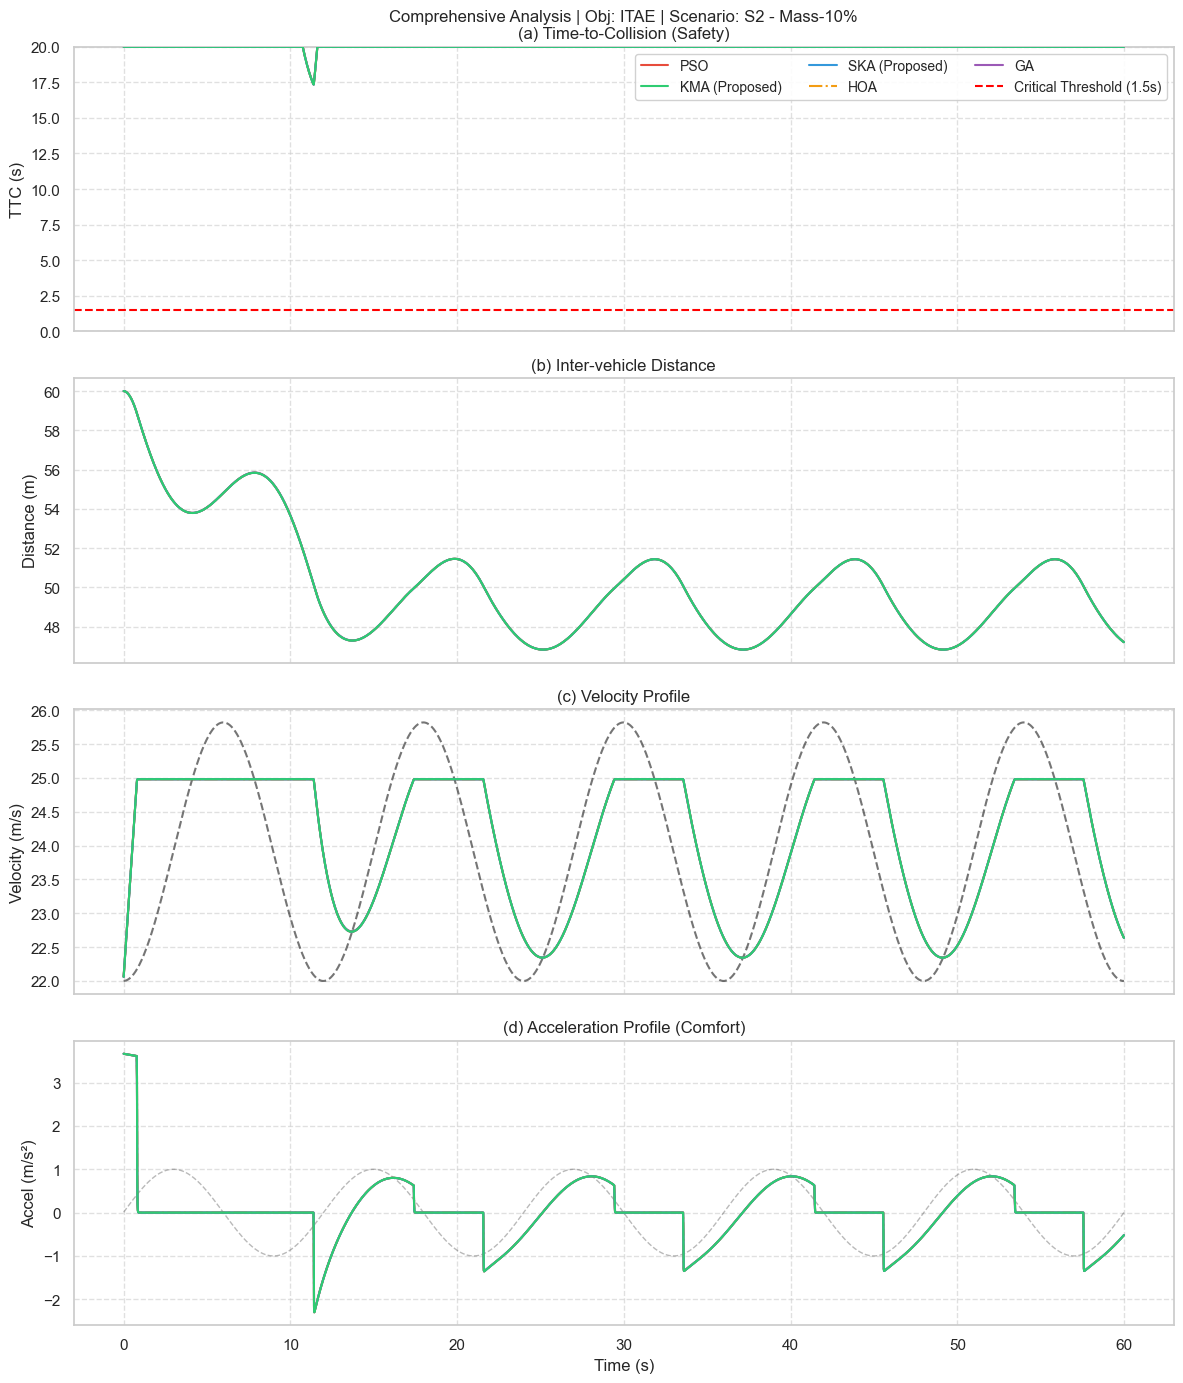

In [56]:
# =========================
# RUN MAIN LOOP
# =========================
TTC_THRESHOLD = 1.5 
GLOBAL_SEED = 123 
results_data = []

print("Running Comprehensive Simulation (Plot + Data)...")

for obj_name, algo_params in params.items():
    print(f"> Processing Objective: {obj_name.upper()}")
    
    for scen in SCENARIOS:
        histories = {}
        scen_id = scen['id']
        scen_desc = scen['desc']
        
        for algo_name, param_vec in algo_params.items():
            obj_val, hist = prastiyanto_sim(
                param_vec,
                objectives[obj_name],
                return_history=True,
                ttc_threshold=TTC_THRESHOLD,
                vehicle_mass=scen['vehicle_mass'],
                theta_angle=scen['theta_angle'],
                rolling_resistance=scen['rolling_resistance']
            )
            histories[algo_name] = hist
            
            # Record Data
            acc = np.array(hist['a_ego'])
            jerk = np.diff(acc) * 60.0 if len(acc) > 1 else np.zeros(1)
            
            results_data.append({
                "Objective": obj_name.upper(),
                "ScenarioID": scen_id,
                "Description": scen_desc,
                "Algorithm": algo_name.upper(),
                "Cost": obj_val,
                "TTC_Min": hist["ttc_min"] if hist["ttc_min"] is not None else -1,
                "Max_Jerk": np.max(np.abs(jerk)),
                "ObjectiveValue": obj_val,
            })

        # Save Combined Plot
        fname_combined = f"data/robustness/car_following/scenarios/{obj_name}_{scen_id}_{scen_desc.replace(' ', '_')}.png"
        plot_combined_analysis(obj_name.upper(), histories, fname_combined, f"{scen_id} - {scen_desc}")

# Save All Data
save_simulation_data(results_data)
print("\n[DONE] All plots and data generated successfully!")

In [58]:
from typing import Dict, List, Optional, Tuple

def _interp_crossing_time(t, y, level, idx):
    t0, t1 = t[idx - 1], t[idx]
    y0, y1 = y[idx - 1], y[idx]
    if y1 == y0:
        return float(t1)
    alpha = (level - y0) / (y1 - y0)
    return float(t0 + alpha * (t1 - t0))


def _first_crossing_time(t, y, level, direction="auto"):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) < 2:
        return None

    if direction == "auto":
        direction = "rising" if (y[-1] >= y[0]) else "falling"

    if direction == "rising":
        cond = (y[:-1] < level) & (y[1:] >= level)
    else:
        cond = (y[:-1] > level) & (y[1:] <= level)

    idxs = np.where(cond)[0]
    if idxs.size == 0:
        return None

    i = int(idxs[0] + 1)
    return _interp_crossing_time(t, y, level, i)


def settling_time(t, y, target_value, band, start_time=None):
    """
    Settling time: earliest time after which y stays within +/- band
    around target_value for the rest of the simulation horizon.

    band must be an absolute value, not a ratio.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) == 0:
        return None

    if start_time is not None:
        mask = t >= start_time
        t2, y2 = t[mask], y[mask]
    else:
        t2, y2 = t, y

    if len(t2) == 0:
        return None

    band = abs(float(band))
    outside = np.abs(y2 - target_value) > band

    if not np.any(outside):
        return float(t2[0])

    last_outside_idx = int(np.where(outside)[0][-1])
    if last_outside_idx == len(t2) - 1:
        return None

    return float(t2[last_outside_idx + 1])


def _compute_settling_band(ref, y0, y_ss, tol, band_basis="step"):
    band_basis = band_basis.lower()
    step_amp = abs(ref - y0)

    if band_basis == "reference":
        scale = abs(ref)
    elif band_basis == "steady_state":
        scale = abs(y_ss)
    else:
        scale = step_amp

    if scale == 0:
        scale = max(abs(ref), abs(y_ss), 1.0)

    return float(max(tol * scale, 1e-12))


def step_response_metrics(
    time,
    y,
    ref,
    y0=None,
    steady_window=2.0,
    tol=0.02,
    rise_frac=(0.1, 0.9),
    settling_mode="steady_state",
    settling_band_basis="step",
    fallback_to_steady_state=True,
):
    """
    Notes on settling time:
    - The old implementation measured settling directly to `ref` with a very
      tight default tolerance (0.002). When the final steady-state error was
      larger than the allowed band, settling time became None/NA even though
      the response had visibly settled.
    - The new default is more robust for report generation:
        * tol=0.02 (2% band, standard control convention)
        * settling_mode="steady_state"
      This keeps SteadyStateError as a separate metric while preventing
      systematic NA values on uphill scenarios.
    """
    t = np.asarray(time, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) == 0:
        raise ValueError("Empty time series.")

    if y0 is None:
        y0 = float(y[0])

    t_end = float(t[-1])
    if steady_window is not None and steady_window > 0:
        mask = t >= (t_end - steady_window)
        y_ss = float(np.mean(y[mask])) if np.any(mask) else float(y[-1])
    else:
        y_ss = float(y[-1])

    ss_error = float(ref - y_ss)

    rising = ref >= y0
    direction = "rising" if rising else "falling"

    if rising:
        peak_idx = int(np.argmax(y))
        peak_value = float(y[peak_idx])
        peak_time = float(t[peak_idx])
        overshoot = max(0.0, peak_value - ref)
    else:
        peak_idx = int(np.argmin(y))
        peak_value = float(y[peak_idx])
        peak_time = float(t[peak_idx])
        overshoot = max(0.0, ref - peak_value)

    step_amp = abs(ref - y0)
    overshoot_pct = float(100.0 * overshoot / step_amp) if step_amp > 0 else 0.0

    low_f, high_f = rise_frac
    low_level = y0 + (ref - y0) * low_f
    high_level = y0 + (ref - y0) * high_f

    t10 = _first_crossing_time(t, y, low_level, direction=direction)
    t90 = _first_crossing_time(t, y, high_level, direction=direction)
    rise_time = (t90 - t10) if (t10 is not None and t90 is not None and t90 >= t10) else None

    settling_band = _compute_settling_band(ref=ref, y0=y0, y_ss=y_ss, tol=tol, band_basis=settling_band_basis)

    settling_mode = settling_mode.lower()
    if settling_mode == "reference":
        ts = settling_time(t, y, target_value=ref, band=settling_band, start_time=t10)
        settling_target_used = "reference"
        if ts is None and fallback_to_steady_state:
            ts = settling_time(t, y, target_value=y_ss, band=settling_band, start_time=t10)
            if ts is not None:
                settling_target_used = "steady_state_fallback"
    else:
        ts = settling_time(t, y, target_value=y_ss, band=settling_band, start_time=t10)
        settling_target_used = "steady_state"
        if ts is None and fallback_to_steady_state:
            ts = settling_time(t, y, target_value=ref, band=settling_band, start_time=t10)
            if ts is not None:
                settling_target_used = "reference_fallback"

    return {
        "y0": float(y0),
        "y_ss": float(y_ss),
        "steady_state_error": ss_error,
        "peak_value": peak_value,
        "peak_time": peak_time,
        "overshoot": float(overshoot),
        "overshoot_pct": float(overshoot_pct),
        "t10": t10,
        "t90": t90,
        "rise_time": float(rise_time) if rise_time is not None else None,
        "settling_time": ts,
        "settling_band": settling_band,
        "settling_target_used": settling_target_used,
        "ref": float(ref),
        "tol": float(tol),
    }


def simulate_cruise_control(
    params,
    obj_fun,
    sim_time=60.0,
    theta_angle=0.0,
    vehicle_mass=1500.0,
    rolling_resistance=0.06,
    v_ref_init=25.0,
    v_ego_init=22.0,
    Ts=1 / 60,
):
    physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)

    verr_gain, vx_gain, xerr_gain = params
    _ = vx_gain, xerr_gain

    vset = float(v_ref_init)
    xego, vego, aego = 0.0, float(v_ego_init), 0.0

    xlead, vlead = 60.0, 22.0
    ddef, Tg = 20.0, 1.2

    obj_val = 0.0
    simulation_steps = int(sim_time / Ts)

    history = {
        "time": [],
        "v_ego": [],
        "v_ref": [],
        "u": [],
        "a_ego": [],
        "tractive_force": [],
    }

    for i in range(simulation_steps):
        t = i * Ts

        dactual = xlead - xego
        dsafe = ddef + Tg * vego
        derr = dsafe - dactual
        verr = vset - vego

        u = verr_gain * verr

        vego, aego, Ft = physics.step(vego, u, Ts)
        xego += vego * Ts

        err = error_synthesizer(derr, verr, 0, t, obj_fun)
        obj_val += err

        history["time"].append(t)
        history["v_ego"].append(vego)
        history["v_ref"].append(vset)
        history["u"].append(u)
        history["a_ego"].append(aego)
        history["tractive_force"].append(Ft)

    return float(obj_val), history


def _ordered_keys(source_dict, preferred_order):
    keys = list(source_dict.keys())
    normalized = {k.lower(): k for k in keys}

    ordered = [normalized[k] for k in preferred_order if k in normalized]
    remaining = [k for k in keys if k not in ordered]
    return ordered + remaining


def build_report_row(objective_name: str, algorithm_name: str, scenario: dict, metrics: dict, obj_val: float):
    return {
        "Objective": objective_name.upper(),
        "Algorithm": algorithm_name.upper(),
        "ScenarioID": scenario["id"],
        "Description": scenario["desc"],
        "RiseTime": metrics["rise_time"],
        "SettlingTime": metrics["settling_time"],
        "OvershootPct": metrics["overshoot_pct"],
        "SteadyStateError": metrics["steady_state_error"],
        "PeakTime": metrics["peak_time"],
        "ObjectiveValue": float(obj_val),
    }


def save_report_csv(rows, output_folder="data/robustness/cruise_control/results", filename="cruise_control_robustness_report.csv"):
    os.makedirs(output_folder, exist_ok=True)
    csv_path = os.path.join(output_folder, filename)

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=REPORT_COLUMNS)
        writer.writeheader()
        for row in rows:
            writer.writerow({col: row.get(col) for col in REPORT_COLUMNS})

    return csv_path


def save_report_txt(rows, output_folder="data/robustness/cruise_control/results", filename="cruise_control_robustness_report.txt"):
    os.makedirs(output_folder, exist_ok=True)
    txt_path = os.path.join(output_folder, filename)

    headers = REPORT_COLUMNS
    widths = {h: len(h) for h in headers}

    def fmt_value(v):
        if v is None:
            return "NA"
        if isinstance(v, float):
            return f"{v:.6f}"
        return str(v)

    rendered_rows = []
    for row in rows:
        rendered = {h: fmt_value(row.get(h)) for h in headers}
        rendered_rows.append(rendered)
        for h, val in rendered.items():
            widths[h] = max(widths[h], len(val))

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("CRUISE CONTROL ROBUSTNESS REPORT\n")
        f.write("================================\n")
        f.write(
            "Columns follow the CSV report: "
            + ", ".join(headers)
            + "\n\n"
        )
        header_line = " | ".join(h.ljust(widths[h]) for h in headers)
        sep_line = "-" * len(header_line)
        f.write(header_line + "\n")
        f.write(sep_line + "\n")
        for row in rendered_rows:
            line = " | ".join(row[h].rjust(widths[h]) for h in headers)
            f.write(line + "\n")

    return txt_path


def plot_cruise_robustness_analysis(obj_name, histories, outpath, scenario_desc):
    any_hist = next(iter(histories.values()))
    time = np.asarray(any_hist["time"], dtype=float)
    ref = np.asarray(any_hist["v_ref"], dtype=float)

    fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

    styles = {
        "pso": {"c": "#e74c3c", "ls": "-",  "lw": 1.8, "z": 3},
        "kma": {"c": "#2ecc71", "ls": "-",  "lw": 1.8, "z": 5},
        "ska": {"c": "#3498db", "ls": "-",  "lw": 1.8, "z": 4},
        "hoa": {"c": "#f39c12", "ls": "-.", "lw": 1.8, "z": 2},
        "ga":  {"c": "#9b59b6", "ls": "-",  "lw": 1.8, "z": 1},
    }

    ax = axes[0]
    ax.plot(time, ref, "k--", lw=1.5, alpha=0.8, label="Reference")
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {"c": "gray", "ls": "-", "lw": 1.5, "z": 1})
        label = algo.upper() + (" (Proposed)" if algo.lower() in ["kma", "ska"] else "")
        ax.plot(time, hist["v_ego"], color=st["c"], ls=st["ls"], lw=st["lw"], label=label, zorder=st["z"])
    ax.set_ylabel("Speed (m/s)")
    ax.set_title(f"Cruise-Control Robustness | Obj: {obj_name} | Scenario: {scenario_desc}\n(a) Velocity Tracking")
    ax.grid(True, ls="--", alpha=0.6)
    ax.legend(loc="lower right", fontsize="small", framealpha=0.9, ncol=3)

    ax = axes[1]
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {"c": "gray", "ls": "-", "lw": 1.5, "z": 1})
        err = np.asarray(hist["v_ref"]) - np.asarray(hist["v_ego"])
        ax.plot(time, err, color=st["c"], ls=st["ls"], lw=st["lw"], zorder=st["z"])
    ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.6)
    ax.set_ylabel("Speed Error (m/s)")
    ax.set_title("(b) Speed Tracking Error")
    ax.grid(True, ls="--", alpha=0.6)

    ax = axes[2]
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {"c": "gray", "ls": "-", "lw": 1.5, "z": 1})
        ax.plot(time, hist["a_ego"], color=st["c"], ls=st["ls"], lw=st["lw"], zorder=st["z"])
    ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.6)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Accel (m/s²)")
    ax.set_title("(c) Acceleration Profile")
    ax.grid(True, ls="--", alpha=0.6)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=220)
    plt.close(fig)

REPORT_COLUMNS = [
    "Objective",
    "Algorithm",
    "ScenarioID",
    "Description",
    "RiseTime",
    "SettlingTime",
    "OvershootPct",
    "SteadyStateError",
    "PeakTime",
    "ObjectiveValue",
]

DEFAULT_OBJECTIVE_ORDER = ["itae", "iae", "ise", "itse"]
DEFAULT_ALGORITHM_ORDER = ["kma", "ga", "hoa", "pso", "ska"]

In [61]:
def run_cruise_control_robustness(
    params: Dict[str, Dict[str, List[float]]],
    ref: float = 25.0,
    sim_time: float = 60.0,
    tol: float = 0.02,
    steady_window: float = 2.0,
    output_root: str = "data/robustness/cruise_control",
    objective_order: Optional[List[str]] = None,
    algorithm_order: Optional[List[str]] = None,
    save_plots: bool = True,
    settling_mode: str = "steady_state",
    settling_band_basis: str = "step",
    fallback_to_steady_state: bool = True,
):
    if not params:
        raise ValueError("params kosong. Load parameter terbaikmu dulu sebelum memanggil robustness.")

    if tol <= 0:
        raise ValueError("tol harus > 0.")

    objective_order = objective_order or DEFAULT_OBJECTIVE_ORDER
    algorithm_order = algorithm_order or DEFAULT_ALGORITHM_ORDER

    ordered_objectives = _ordered_keys(params, objective_order)
    results_data = []
    all_histories = {}

    scenario_plot_dir = os.path.join(output_root, "scenarios")
    if save_plots:
        os.makedirs(scenario_plot_dir, exist_ok=True)

    print("Running cruise-control robustness benchmark...")
    print(
        f"[INFO] settling_mode={settling_mode}, settling_band_basis={settling_band_basis}, "
        f"tol={tol}, steady_window={steady_window}"
    )

    for obj_name in ordered_objectives:
        algo_params = params[obj_name]
        obj_key = obj_name.lower()
        if obj_key not in objectives:
            raise KeyError(f"Objective '{obj_name}' tidak ada di objectives mapping.")

        print(f"> Processing Objective: {obj_name.upper()}")
        all_histories[obj_key] = {}

        ordered_algorithms = _ordered_keys(algo_params, algorithm_order)

        for algo_name in ordered_algorithms:
            param_vec = algo_params[algo_name]
            algo_key = algo_name.lower()
            all_histories[obj_key][algo_key] = {}

            for scen in SCENARIOS:
                obj_val, hist = simulate_cruise_control(
                    param_vec,
                    objectives[obj_key],
                    sim_time=sim_time,
                    theta_angle=scen["theta_angle"],
                    vehicle_mass=scen["vehicle_mass"],
                    rolling_resistance=scen["rolling_resistance"],
                    v_ref_init=ref,
                )

                metrics = step_response_metrics(
                    time=hist["time"],
                    y=hist["v_ego"],
                    ref=ref,
                    steady_window=steady_window,
                    tol=tol,
                    settling_mode=settling_mode,
                    settling_band_basis=settling_band_basis,
                    fallback_to_steady_state=fallback_to_steady_state,
                )

                results_data.append(build_report_row(obj_name, algo_name, scen, metrics, obj_val))
                all_histories[obj_key][algo_key][scen["id"]] = hist

        if save_plots:
            for scen in SCENARIOS:
                scen_id = scen["id"]
                scen_desc = scen["desc"]
                histories = {
                    algo_name: all_histories[obj_key][algo_name.lower()][scen_id]
                    for algo_name in ordered_algorithms
                }
                fname_plot = os.path.join(
                    scenario_plot_dir,
                    f"{obj_key}_{scen_id}_{scen_desc.replace(' ', '_').replace('%', 'pct')}.png",
                )
                plot_cruise_robustness_analysis(obj_name.upper(), histories, fname_plot, f"{scen_id} - {scen_desc}")

    results_dir = os.path.join(output_root, "results")
    csv_path = save_report_csv(results_data, results_dir)
    txt_path = save_report_txt(results_data, results_dir)
    print(f"[DONE] CSV saved to: {csv_path}")
    print(f"[DONE] TXT saved to: {txt_path}")

    return {
        "results": results_data,
        "histories": all_histories,
        "csv_path": csv_path,
        "txt_path": txt_path,
    }

robustness_out = run_cruise_control_robustness(params)

Running cruise-control robustness benchmark...
[INFO] settling_mode=steady_state, settling_band_basis=step, tol=0.02, steady_window=2.0
> Processing Objective: ITAE
> Processing Objective: IAE
> Processing Objective: ISE
> Processing Objective: ITSE
[DONE] CSV saved to: data/robustness/cruise_control\results\cruise_control_robustness_report.csv
[DONE] TXT saved to: data/robustness/cruise_control\results\cruise_control_robustness_report.txt


### Plot out the metric charts

C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


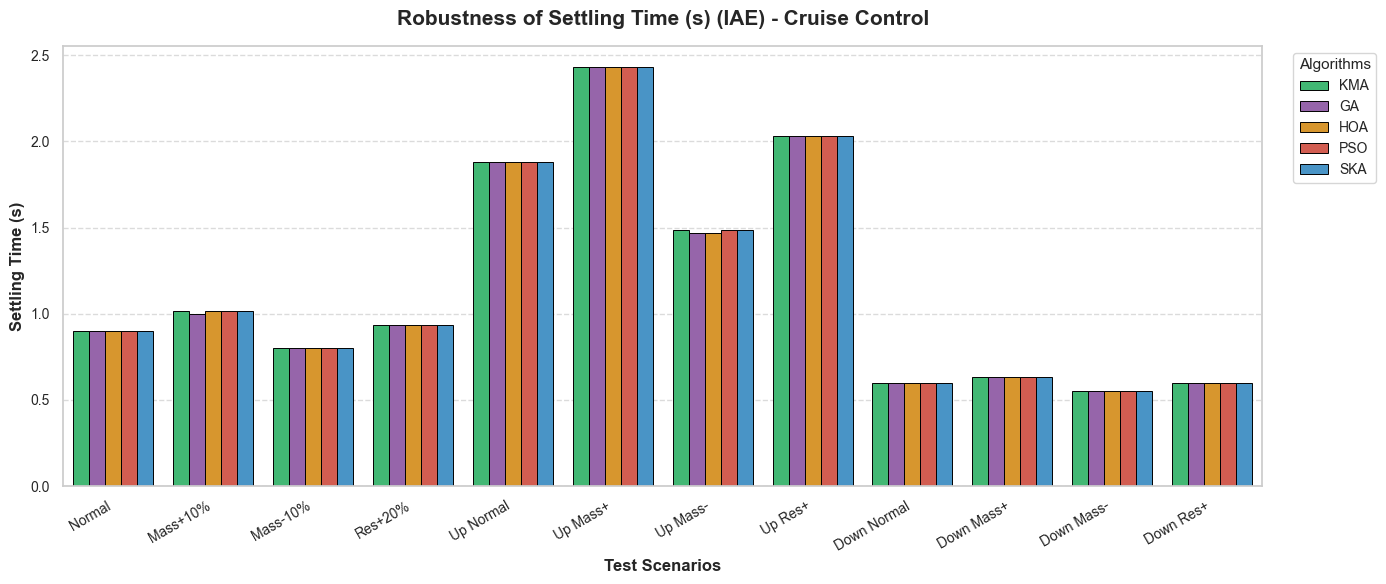

Plot berhasil disimpan: data/robustness/cruise_control/plots/SettlingTime\robustness_cruise_control_iae_settlingtime.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


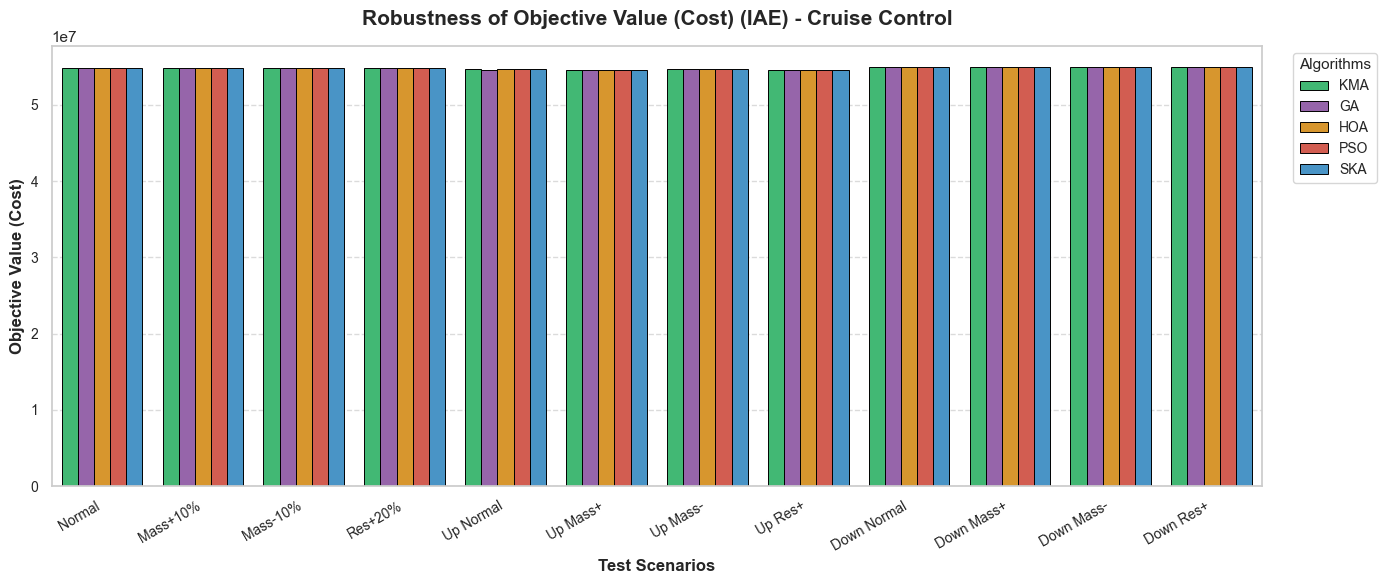

Plot berhasil disimpan: data/robustness/cruise_control/plots/ObjectiveValue\robustness_cruise_control_iae_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


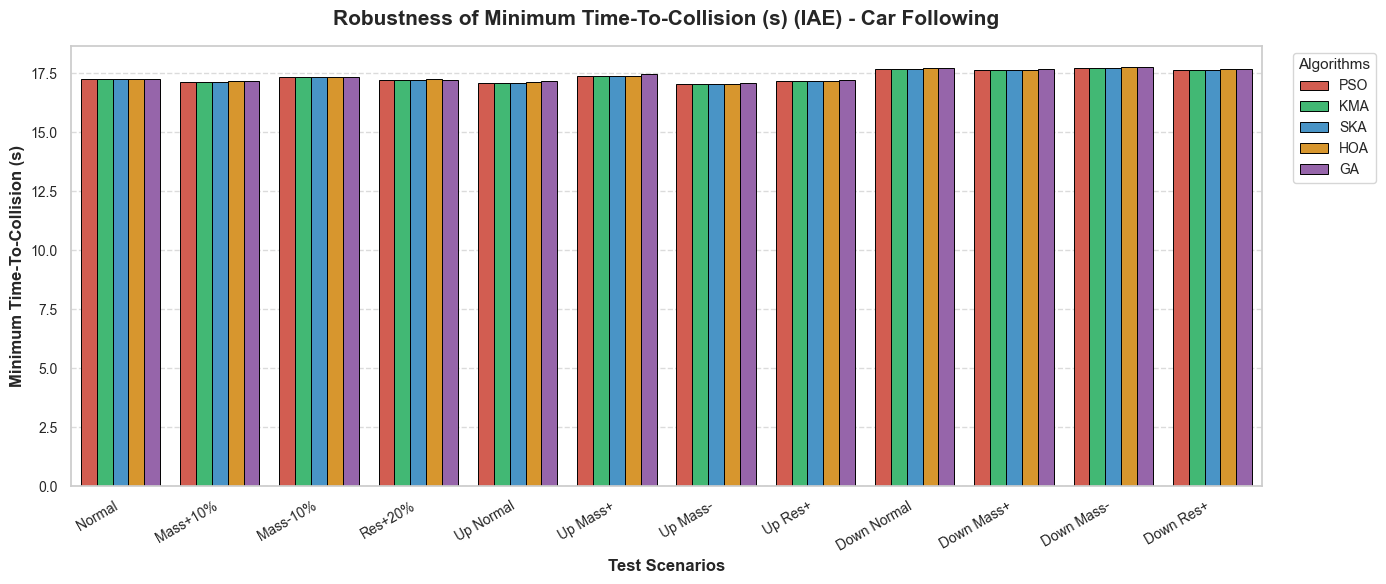

Plot berhasil disimpan: data/robustness/car_following/plots/TTC_Min\robustness_car_following_iae_ttc_min.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


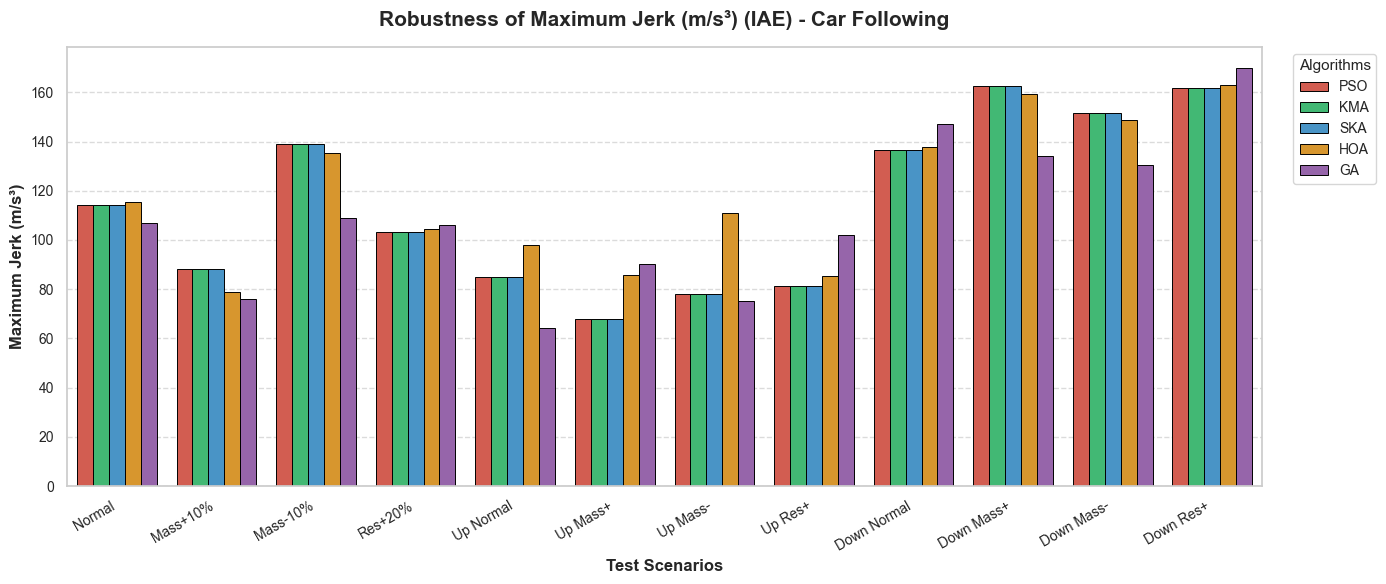

Plot berhasil disimpan: data/robustness/car_following/plots/Max_Jerk\robustness_car_following_iae_max_jerk.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


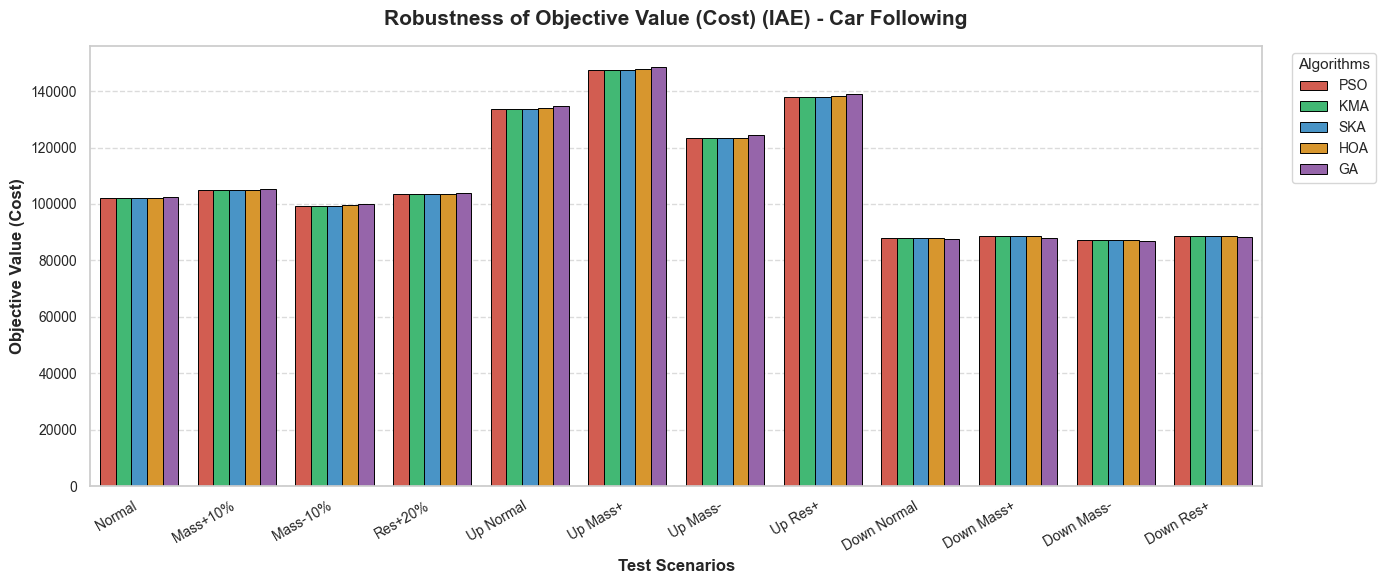

Plot berhasil disimpan: data/robustness/car_following/plots/ObjectiveValue\robustness_car_following_iae_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


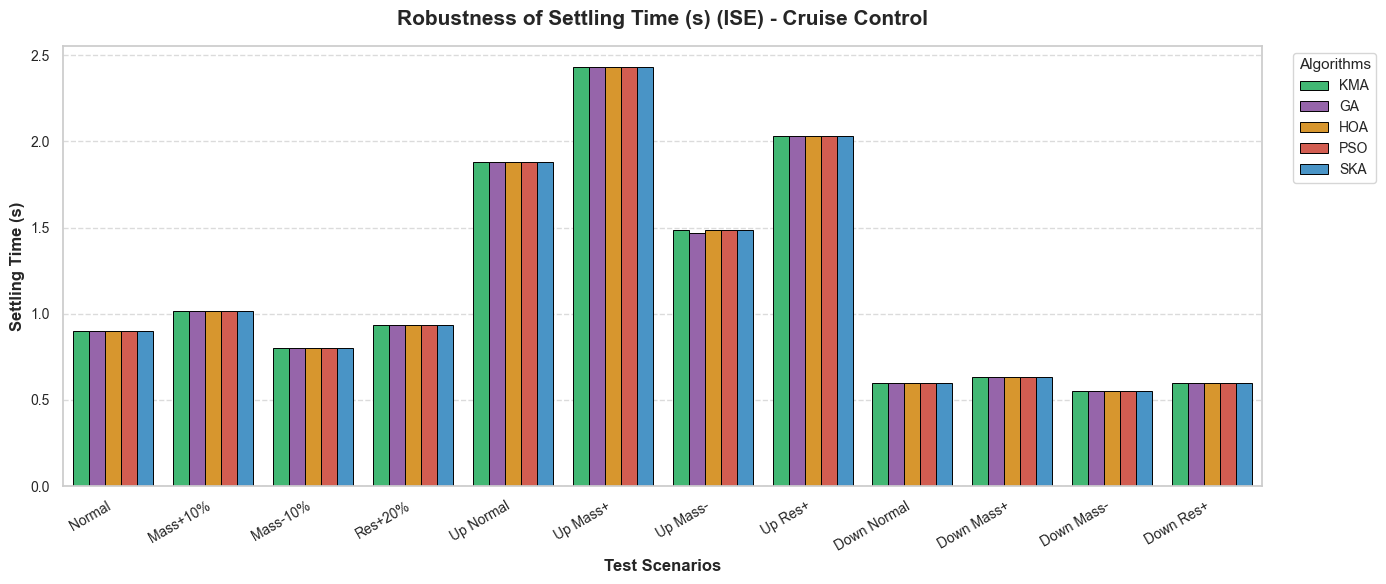

Plot berhasil disimpan: data/robustness/cruise_control/plots/SettlingTime\robustness_cruise_control_ise_settlingtime.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


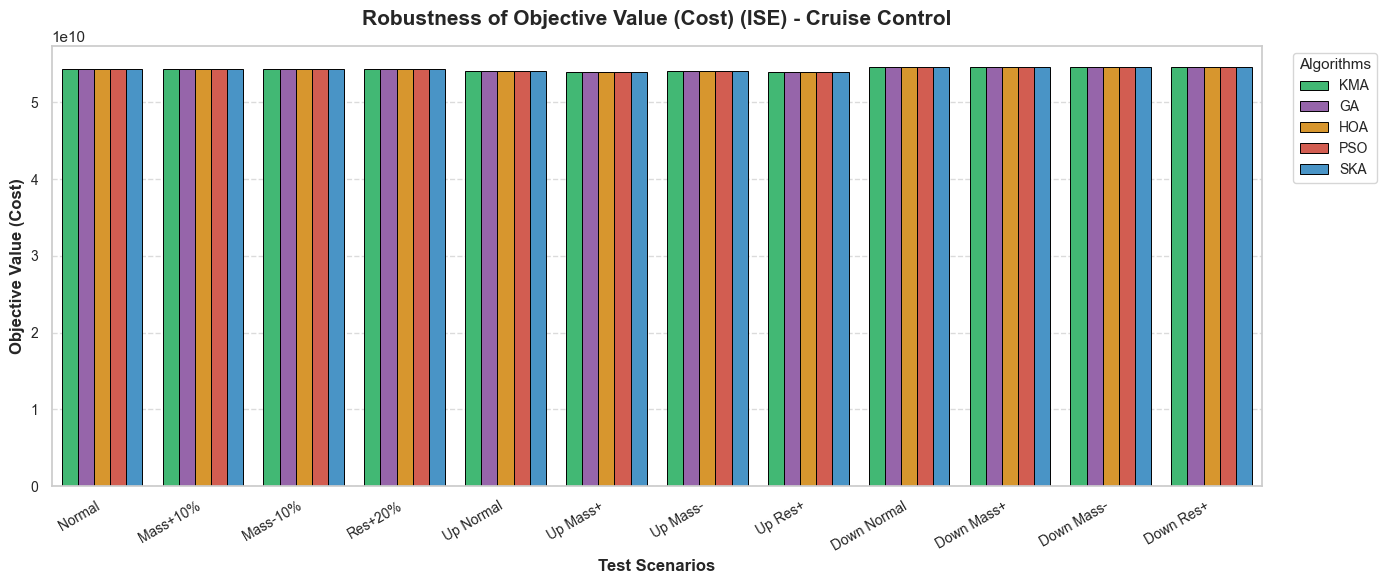

Plot berhasil disimpan: data/robustness/cruise_control/plots/ObjectiveValue\robustness_cruise_control_ise_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


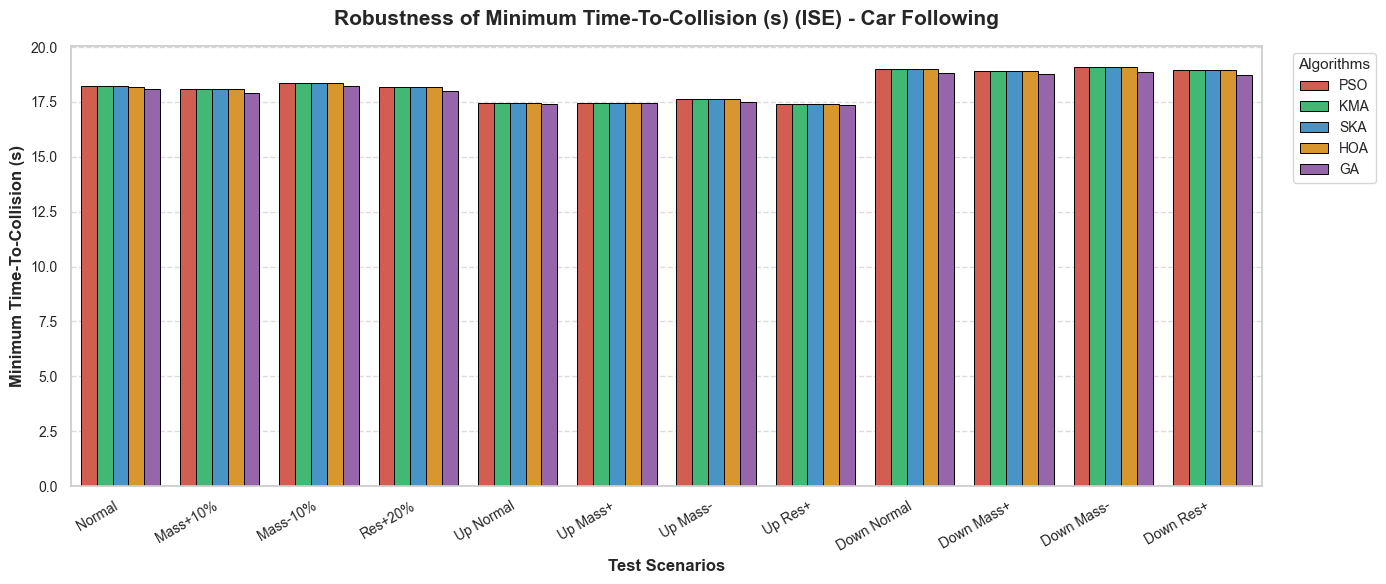

Plot berhasil disimpan: data/robustness/car_following/plots/TTC_Min\robustness_car_following_ise_ttc_min.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


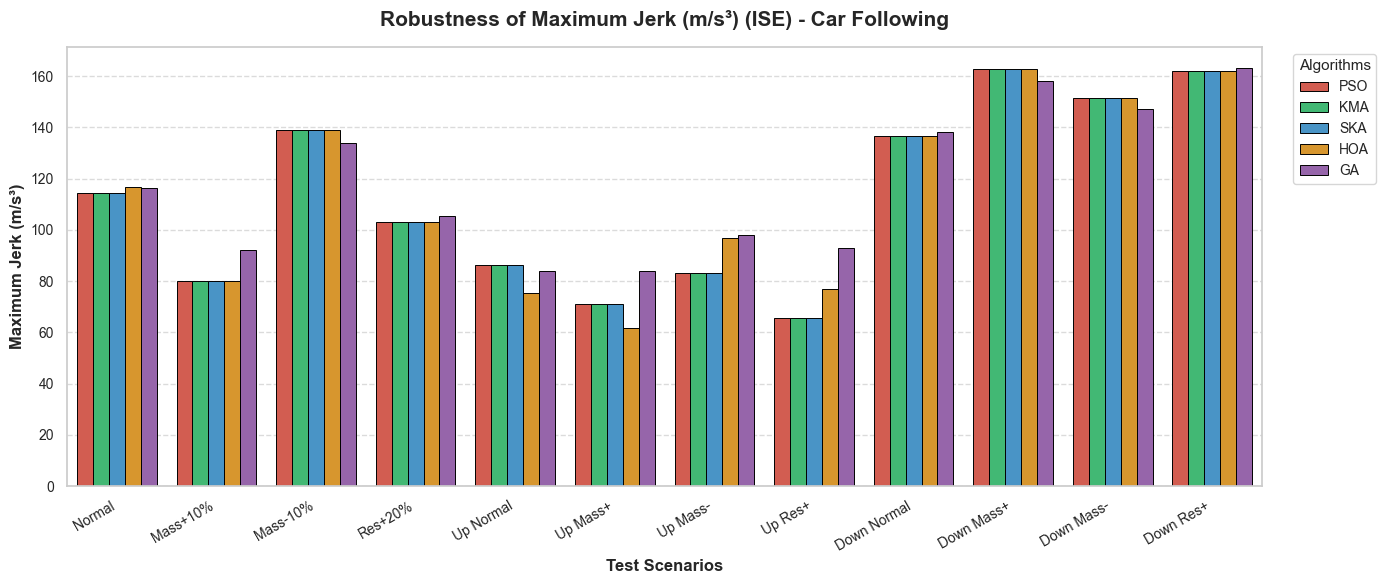

Plot berhasil disimpan: data/robustness/car_following/plots/Max_Jerk\robustness_car_following_ise_max_jerk.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


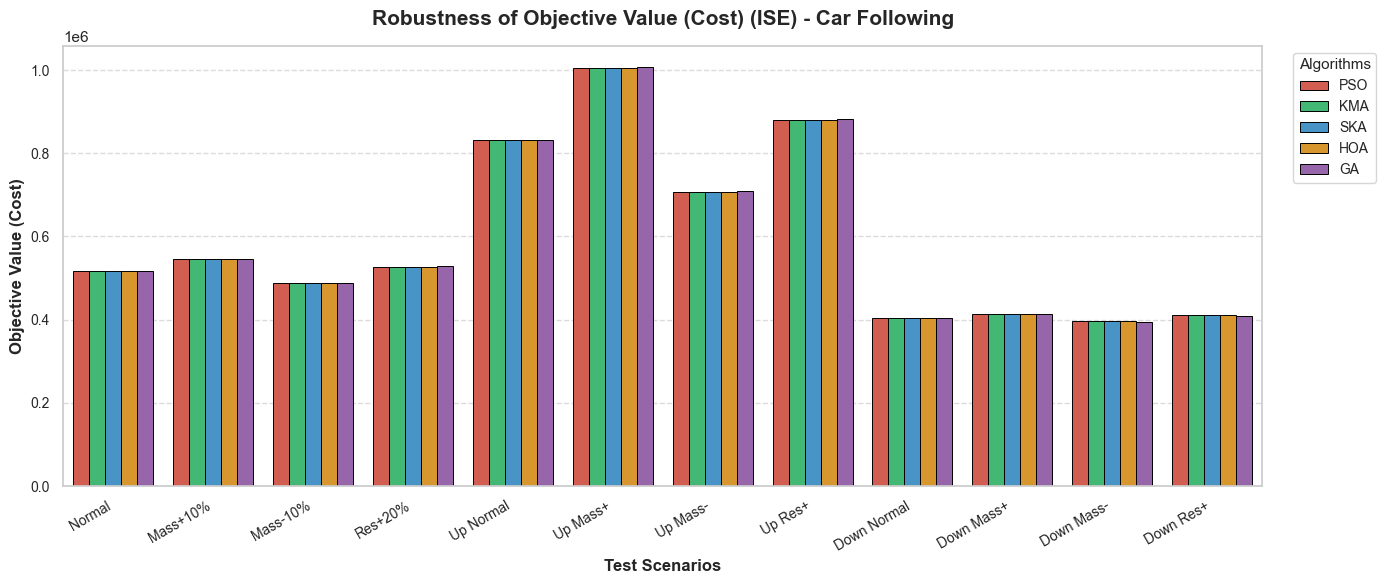

Plot berhasil disimpan: data/robustness/car_following/plots/ObjectiveValue\robustness_car_following_ise_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


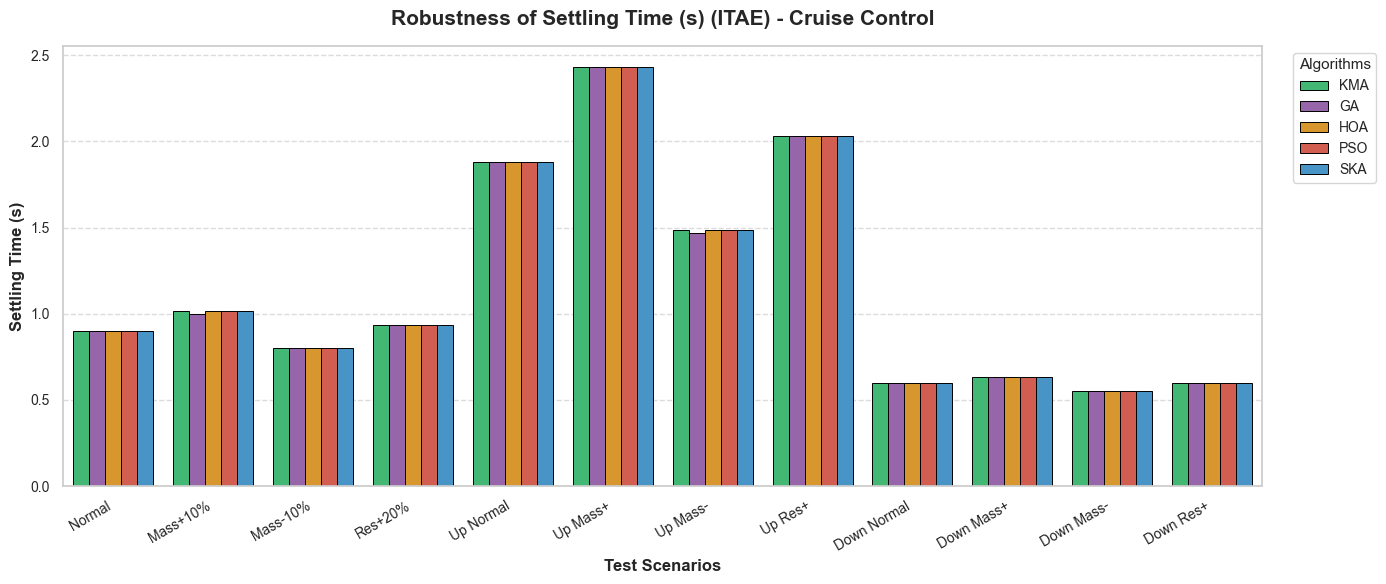

Plot berhasil disimpan: data/robustness/cruise_control/plots/SettlingTime\robustness_cruise_control_itae_settlingtime.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


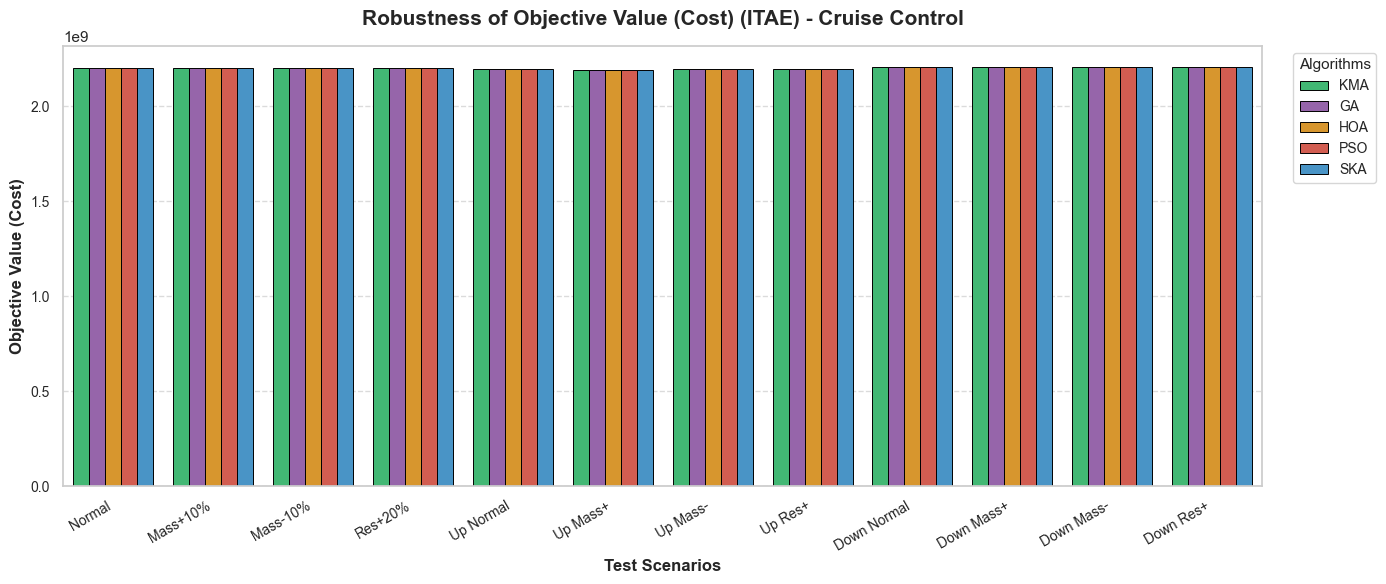

Plot berhasil disimpan: data/robustness/cruise_control/plots/ObjectiveValue\robustness_cruise_control_itae_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


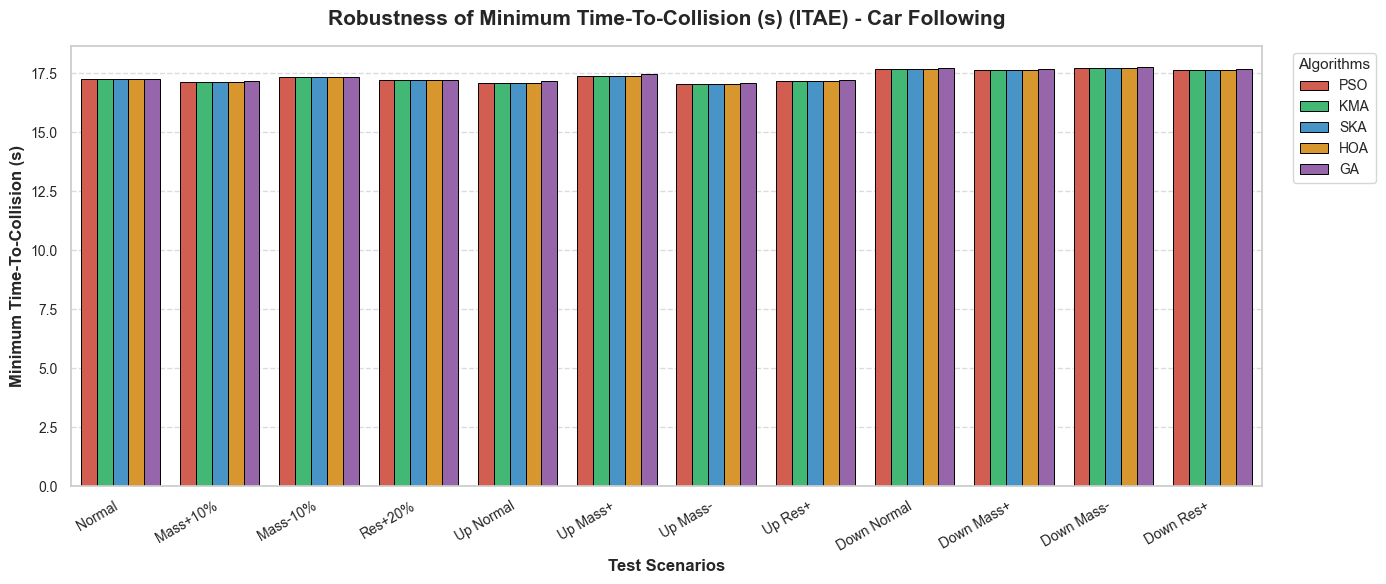

Plot berhasil disimpan: data/robustness/car_following/plots/TTC_Min\robustness_car_following_itae_ttc_min.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


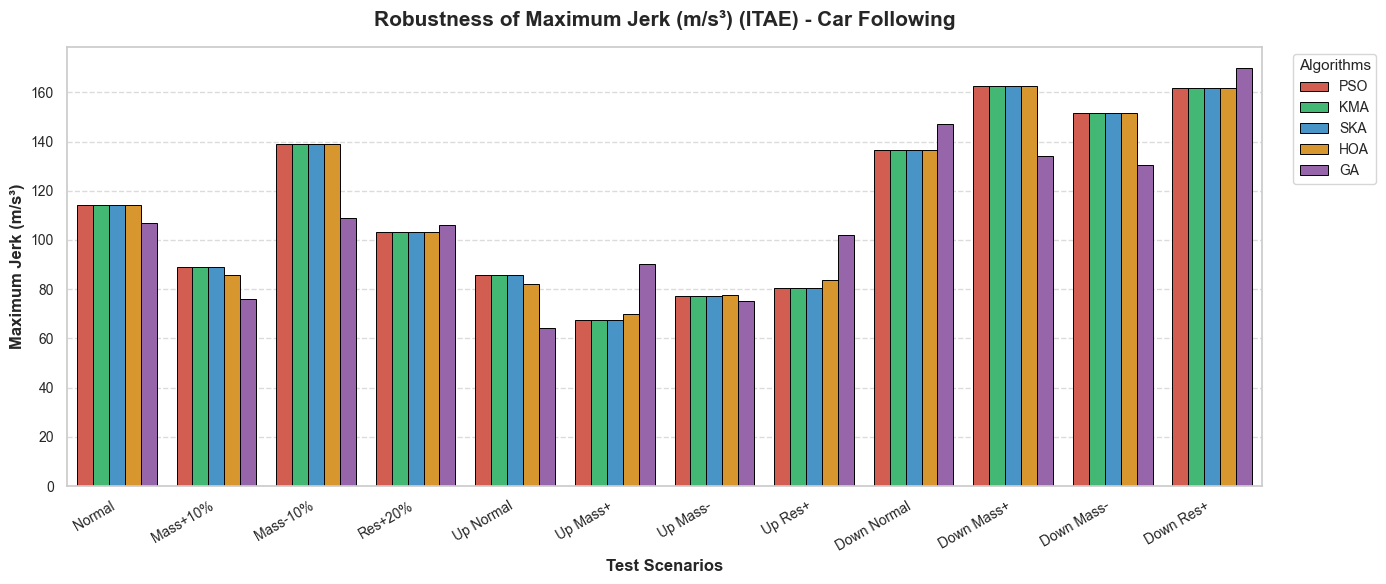

Plot berhasil disimpan: data/robustness/car_following/plots/Max_Jerk\robustness_car_following_itae_max_jerk.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


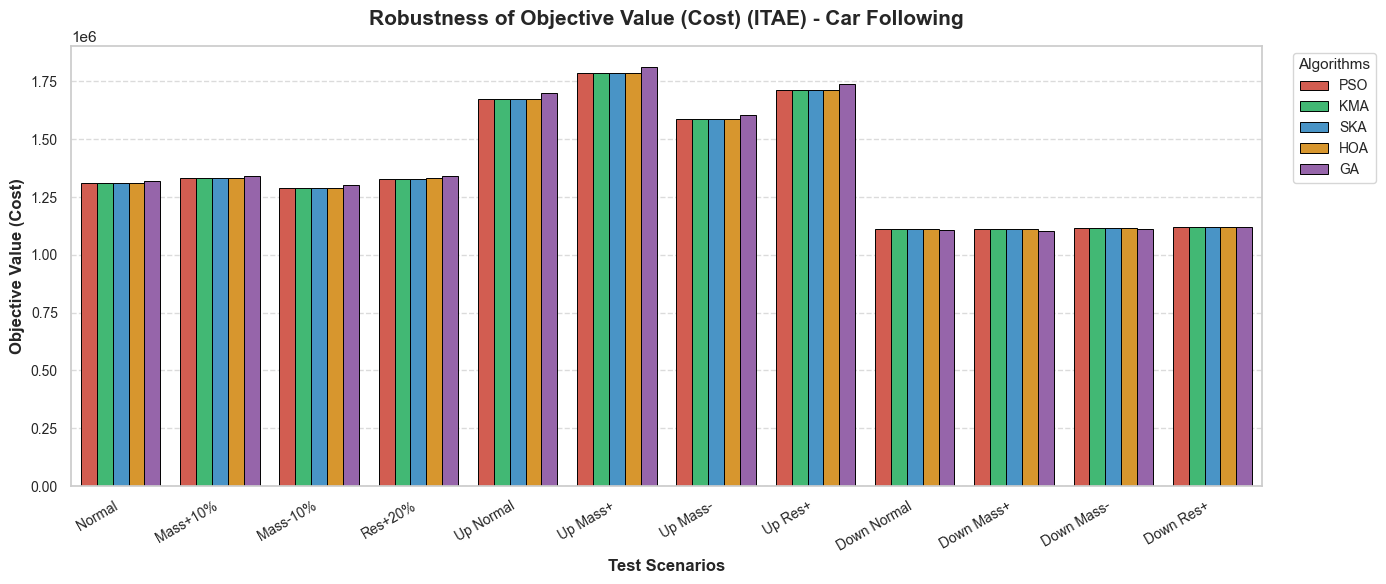

Plot berhasil disimpan: data/robustness/car_following/plots/ObjectiveValue\robustness_car_following_itae_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


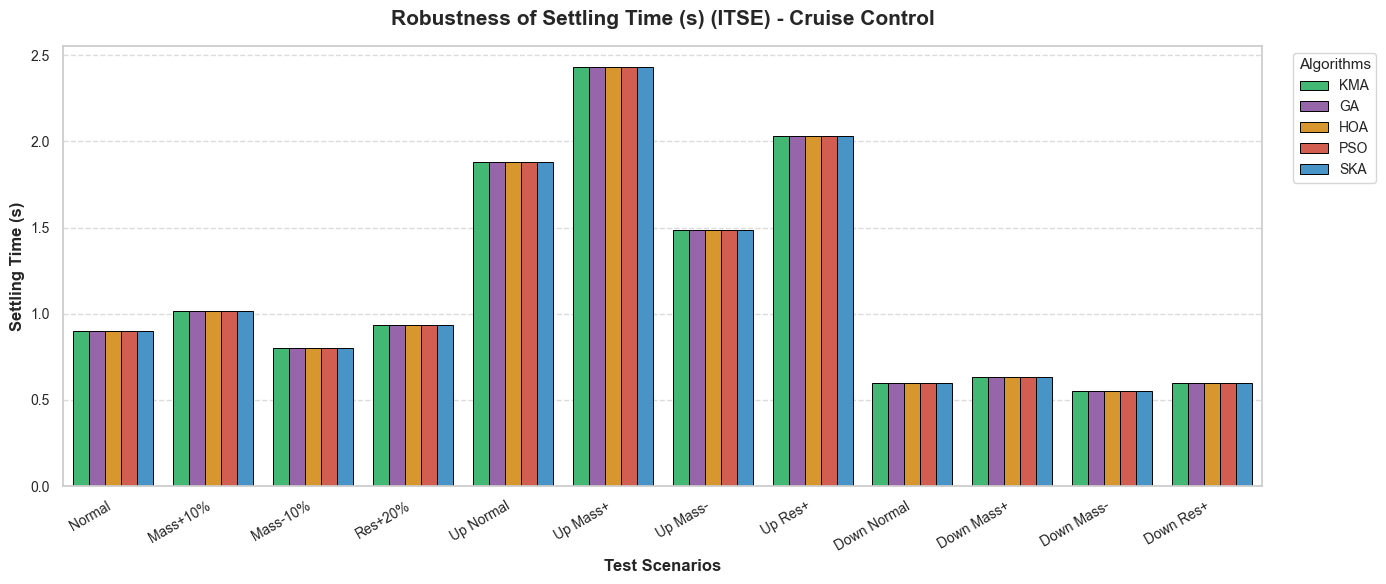

Plot berhasil disimpan: data/robustness/cruise_control/plots/SettlingTime\robustness_cruise_control_itse_settlingtime.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


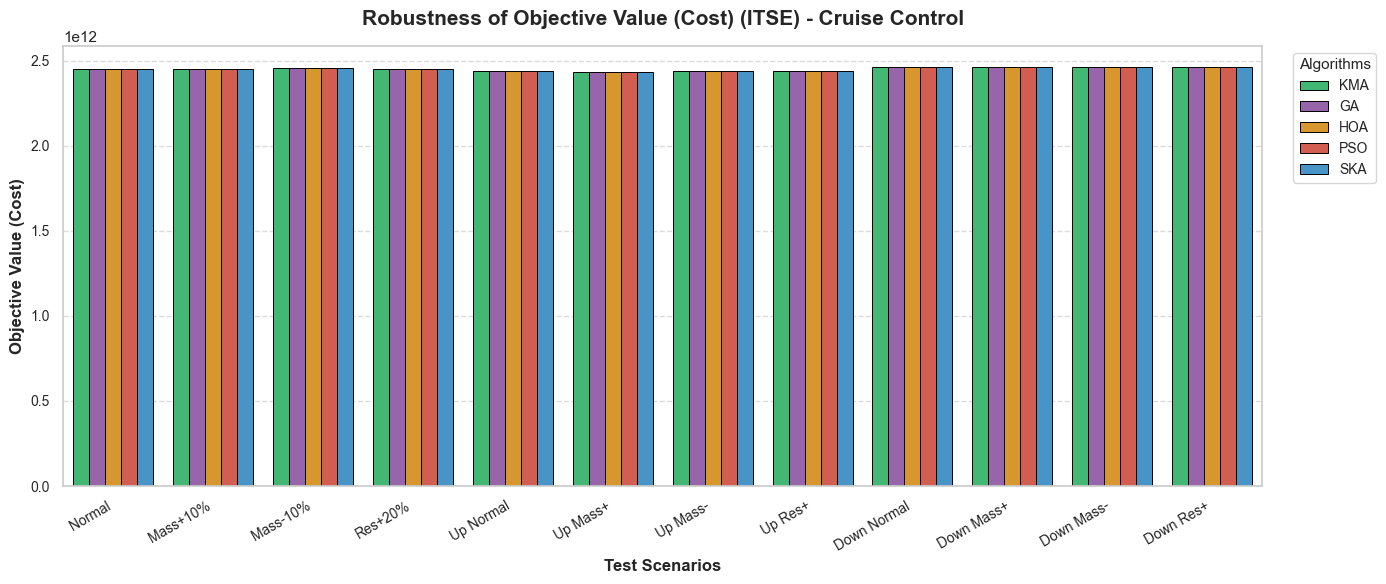

Plot berhasil disimpan: data/robustness/cruise_control/plots/ObjectiveValue\robustness_cruise_control_itse_objectivevalue.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


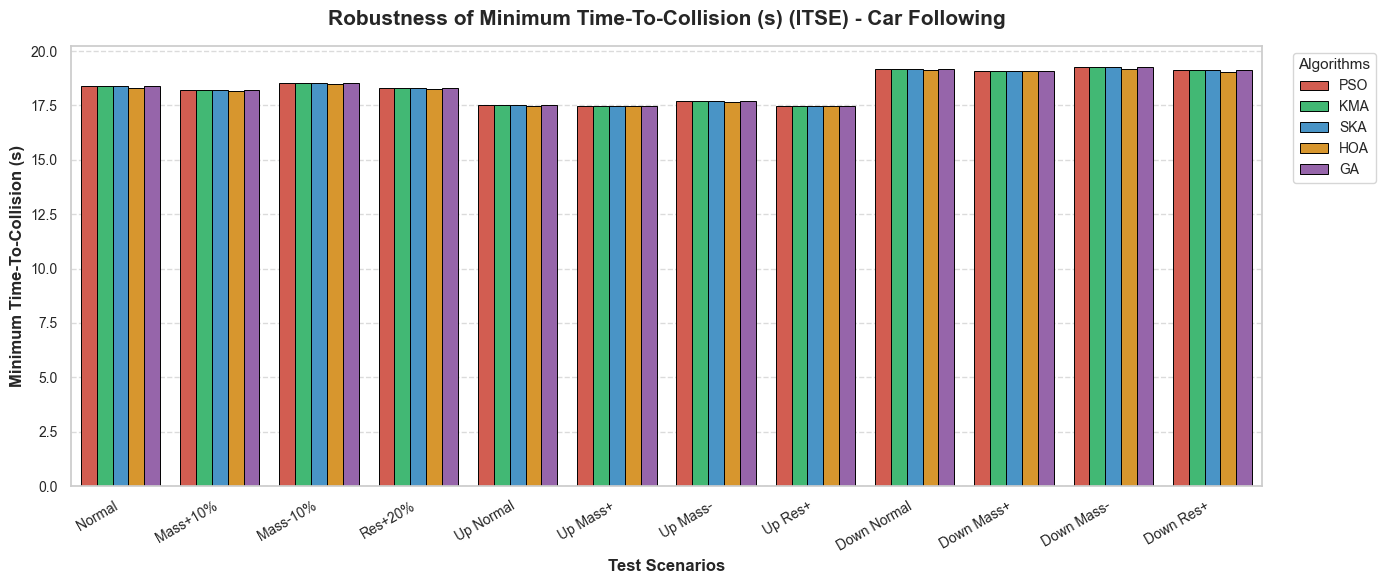

Plot berhasil disimpan: data/robustness/car_following/plots/TTC_Min\robustness_car_following_itse_ttc_min.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


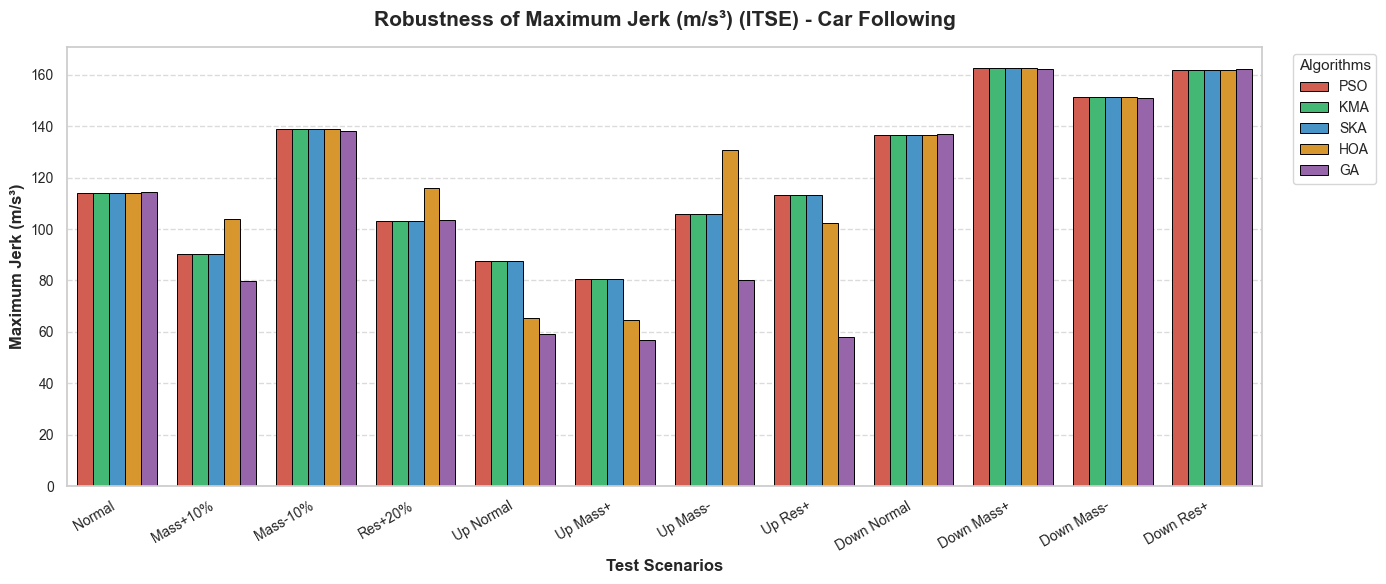

Plot berhasil disimpan: data/robustness/car_following/plots/Max_Jerk\robustness_car_following_itse_max_jerk.png


C:\Users\krnwn\AppData\Local\Temp\ipykernel_39416\2511468288.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()


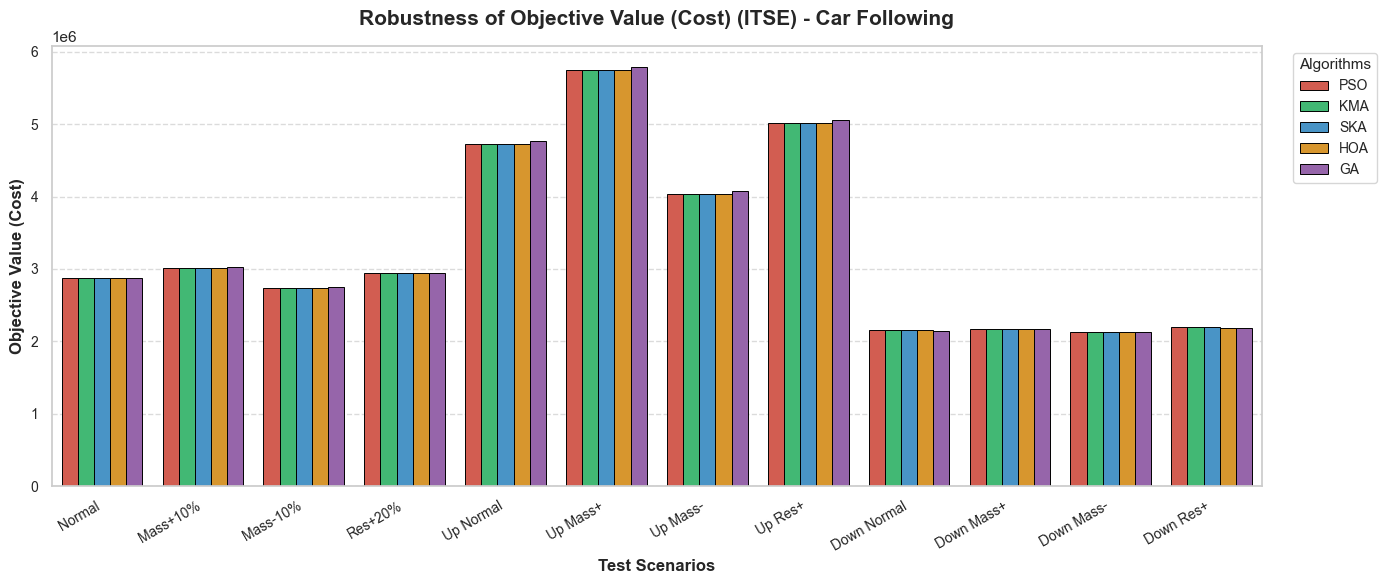

Plot berhasil disimpan: data/robustness/car_following/plots/ObjectiveValue\robustness_car_following_itse_objectivevalue.png


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Konfigurasi Warna Konsisten dengan Plot Sebelumnya
ALGO_COLORS = {
    'PSO': '#e74c3c',  # Merah
    'KMA': '#2ecc71',  # Hijau
    'SKA': '#3498db',  # Biru
    'HOA': '#f39c12',  # Oranye
    'GA':  '#9b59b6',  # Ungu
}

def plot_robustness_metric(csv_file, system_name, objective, metric_col, metric_label, out_dir="data/robustness"):
    """
    Fungsi untuk mem-plot metrik ketahanan (robustness) per Skenario untuk tiap Algoritma.
    """
    # Pastikan file ada
    if not os.path.exists(csv_file):
        print(f"File {csv_file} tidak ditemukan!")
        return
        
    # Buat direktori output jika belum ada
    os.makedirs(out_dir, exist_ok=True)
    
    # Baca data
    df = pd.read_csv(csv_file)
    
    # Filter hanya untuk Objective tertentu (Misal: 'ITAE', 'ITSE')
    # Gunakan str.upper() agar aman dari perbedaan case
    df['Objective'] = df['Objective'].str.upper()
    df_filtered = df[df['Objective'] == objective.upper()]
    
    if df_filtered.empty:
        print(f"Data untuk objective {objective} tidak ditemukan di {csv_file}.")
        return

    # Pastikan algoritma di uppercase
    df_filtered['Algorithm'] = df_filtered['Algorithm'].str.upper()

    # 2. Mulai Plotting
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 6)) # Ukuran kanvas memanjang
    
    # Buat Grouped Barplot menggunakan Seaborn
    ax = sns.barplot(
        data=df_filtered, 
        x='Description', 
        y=metric_col, 
        hue='Algorithm',
        palette=ALGO_COLORS,
        edgecolor='black', # Memberikan garis luar pada bar agar lebih rapi
        linewidth=0.7
    )
    
    # Penyesuaian Visual
    plt.title(f"Robustness of {metric_label} ({objective.upper()}) - {system_name}", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Test Scenarios", fontsize=12, fontweight='bold')
    plt.ylabel(metric_label, fontsize=12, fontweight='bold')
    
    # Rotasi teks di sumbu X agar tidak bertabrakan
    plt.xticks(rotation=30, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    
    # Menyesuaikan posisi Legend
    plt.legend(title='Algorithms', title_fontsize='11', fontsize='10', 
               bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    
    # Tambahkan grid horizontal kecil untuk kemudahan pembacaan
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(False) # Sumbu X tidak perlu grid vertikal

    plt.tight_layout()
    
    # Simpan Gambar
    filename = f"robustness_{system_name.lower().replace(' ', '_')}_{objective.lower()}_{metric_col.lower()}.png"
    out_path = os.path.join(out_dir, filename)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"Plot berhasil disimpan: {out_path}")

data_dir = "data/robustness"

# ==========================================
# EKSEKUSI PLOTTING
# ==========================================

for obj in ['IAE', 'ISE','ITAE', 'ITSE']:
    plot_robustness_metric(
        csv_file=f'{data_dir}/cruise_control/results/cruise_control_robustness_report.csv',
        system_name='Cruise Control',
        objective=obj,
        metric_col='SettlingTime',
        metric_label='Settling Time (s)',
        out_dir=f'{data_dir}/cruise_control/plots/SettlingTime'
    )

    plot_robustness_metric(
        csv_file=f'{data_dir}/cruise_control/results/cruise_control_robustness_report.csv',
        system_name='Cruise Control',
        objective=obj,
        metric_col='ObjectiveValue',
        metric_label='Objective Value (Cost)',
        out_dir=f'{data_dir}/cruise_control/plots/ObjectiveValue'
    )

    plot_robustness_metric(
        csv_file=f'{data_dir}/car_following/results/car_following_metrics.csv',
        system_name='Car Following',
        objective=obj,
        metric_col='TTC_Min',
        metric_label='Minimum Time-To-Collision (s)',
        out_dir=f'{data_dir}/car_following/plots/TTC_Min'
    )

    # 4. Plot untuk Car Following (Misal: Membandingkan Max Jerk untuk kenyamanan)
    plot_robustness_metric(
        csv_file=f'{data_dir}/car_following/results/car_following_metrics.csv',
        system_name='Car Following',
        objective=obj, 
        metric_col='Max_Jerk',
        metric_label='Maximum Jerk (m/s³)',
        out_dir=f'{data_dir}/car_following/plots/Max_Jerk'
    )

    plot_robustness_metric(
        csv_file=f'{data_dir}/car_following/results/car_following_metrics.csv',
        system_name='Car Following',
        objective=obj,
        metric_col='ObjectiveValue',
        metric_label='Objective Value (Cost)',
        out_dir=f'{data_dir}/car_following/plots/ObjectiveValue'
    )